# Unsupervised discovery of phase boundaries with a quantum autoencoder

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Locating a phase transition usually starts from an **order parameter**: a magnetisation, a staggered
magnetisation, a string correlator, chosen because one already knows what orders. For a new model, or for data from a
quantum simulator, that knowledge may be missing. We ask whether the boundaries of a phase diagram can be found from
the ground states alone, without telling the algorithm what to look for.

The idea comes from anomaly detection in machine learning. A model is trained to reproduce "normal" data; on data
unlike the training set it fails, and the size of the failure flags an anomaly. For phase diagrams one trains on
ground states from one region of parameter space and scans the rest: states of the same phase should be reproduced
well and states of other phases badly. Kottmann, Huembeli, Lewenstein and Acín (2020) used deep neural networks
trained for anomaly detection to map the phase diagram of the extended Bose–Hubbard model without supervision. Kottmann, Metz,
Fraxanet and Baldelli (2021) proposed a quantum version, *variational quantum anomaly detection*, which processes the
ground states on the same quantum device that prepares them. Its circuit is modelled on the quantum autoencoder of
Romero, Olson and Aspuru-Guzik (2017)
([notebook 45](../ch11_variational_quantum_circuits/45_quantum_autoencoder.ipynb)): an encoder is trained to drive a
few **trash qubits** of one input state into $\vert0\cdots0\rangle$, and for any other input the residual excitation of
the trash qubits is the anomaly score. They report that a single ground state was enough training data to infer
the three phases of their model.

We study this protocol on a chain of $N=8$ spins with the Hamiltonian

$$H(\Delta,h_x)=J\sum_{i=0}^{N-2}\bigl(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\bigr)+h_x\sum_{i=0}^{N-1}X_i ,
  \tag{1}$$

the XXZ chain in a field transverse to its anisotropy axis, over the plane $-2.5\le\Delta\le2.5$,
$0.1\le h_x/J\le5$. Because $N=8$ is small, every ground state is available exactly, and so is every observable one
might have chosen as an order parameter. The exact data serve as the reference against which the anomaly maps are
judged.

**Road map.**

* **Section 3** computes the 2050 ground states of the grid by Lanczos inside the two sectors of the spin-flip
  symmetry of Eq. (1), and draws the reference phase diagram from exact observables. The finite chain has sharp lines
  (level crossings and a narrowly avoided crossing) and smooth crossovers, which we compare with the phase diagram of
  the infinite chain.
* **Section 4** defines the anomaly score. The local Hamming cost $D_H$ of the trash register and the global trash
  infidelity $1-p_0$ are bounded by each other, $D_H\le1-p_0\le kD_H$; the score of a frozen encoder is bounded by the
  infidelity of the input with the training state; the encoder with all angles zero scores exactly $1/2$ on every
  ground state. We also measure how the gradients of the two costs compare at random initialisation.
* **Section 5** trains encoders at four reference points, with the step size bracketed for both costs and success
  statistics over random starts.
* **Section 6** applies the frozen encoders to all ground states, tests them against untrained encoders, and
  compares the maps with exact data along two cuts: one through the avoided crossing at small field, and one through
  the field-induced transition from the ferromagnet to the field-polarised phase, where the exact finite-size
  precursors are followed at $N=6$, $8$ and $10$. It closes by varying the number of trash qubits.
* **Section 7** lists what limits the method.

### What you will learn

*Physics*

* how a symmetry of the Hamiltonian organises the ground states of a finite chain, and why states of opposite
  symmetry are exactly orthogonal;
* how the phase diagram of the infinite chain appears at $N=8$: an avoided crossing at a phase boundary, level
  crossings inside the symmetry-broken phases, and a smooth crossover in place of an Ising-type transition, whose
  finite-size precursors (fidelity-susceptibility peak, scaled gap) move towards the critical field as $N$ grows;
* what the anomaly score of a frozen autoencoder measures, and what it does not.

*Numerical methods*

* Lanczos restricted to a symmetry sector, in real arithmetic, for a whole parameter grid at once;
* inequalities that connect a local cost, a global cost and an overlap, and their numerical checks;
* controls for an unsupervised method: an untrained encoder, the identity encoder, a second reference point, and
  statistics over random starts with Wilson intervals.

*Implementation practice*

* one compiled program for 4100 Lanczos runs, and one for many training runs that differ in cost function, step size,
  input state and trash register, all entering as traced arrays;
* the trash register as a 0/1 mask, so that changing it does not trigger a recompilation;
* separating compilation time from execution time with `jax.jit(...).lower(...).compile()`.

### Prerequisites

* [45 — the quantum autoencoder](../ch11_variational_quantum_circuits/45_quantum_autoencoder.ipynb): encoder, trash,
  decoder; the bounds $F_{\rm trash}^2\le F_{\rm rec}\le F_{\rm trash}$ of its Section 4.2;
* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  the hardware-efficient ansatz, global and local costs (Section 5.3), barren plateaus (Section 13);
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam, training loops as `lax.scan`,
  choosing the step size by measurement (Section 11);
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Lanczos and symmetry sectors.

The ground-state fidelity and the Kosterlitz–Thouless point of the XXZ chain, both mentioned below, are treated in
[47 — quantum phase transitions](../ch13_quantum_phase_transitions/47_quantum_phase_transitions.ipynb), Sections 7
and 10.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

The notebook needs the gate machinery and the hardware-efficient ansatz, the term-list Hamiltonian with its
matrix-free product, two Lanczos solvers (the restarted one of notebook 11 for a check, and the compiled
`lanczos_lowest` for the grid), reduced density matrices and the entanglement entropy.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def lanczos_lowest(matvec, v0, m, mask=None, key=None):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    BREAKDOWN  beta_j <= 1e-12 ||H||, with ||H|| estimated by the largest ||H v_j|| seen (a RELATIVE test: the rounding
            residual of an exhausted Krylov space grows with ||H||).  The Krylov space K is then invariant, but it need
            not contain the lowest eigenvector (v0 orthogonal to it, e.g. v0 an eigenvector or in another symmetry
            sector).  Lanczos therefore RESTARTS from a random vector of the allowed space (`mask`), orthogonalised
            against K, and writes beta_j = 0 into T: T becomes block diagonal and every Ritz value belongs to H.  Only if
            nothing is left (the whole allowed space is exhausted) do the remaining rows of T get a diagonal far above
            the spectrum, so that their spurious eigenvalues cannot be the lowest.
    ARGUMENTS  mask (shape of v0, 0/1, optional): the subspace H acts on; the restart vectors are drawn inside it.
            key: PRNG key of the restart vectors (default PRNGKey(0): deterministic).
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    mask = jnp.ones(v0.size, dtype=RDTYPE) if mask is None else jnp.asarray(mask, dtype=RDTYPE).reshape(-1)
    key = jax.random.PRNGKey(0) if key is None else key
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def orthogonalise(w, V):                                     # w <- w - sum_i v_i <v_i|w>, twice (rounding); V holds the v_i as ROWS
        w = w - jnp.conj(V @ jnp.conj(w)) @ V
        return w - jnp.conj(V @ jnp.conj(w)) @ V

    def body(carry, j):
        V, v, v_prev, beta_prev, alive, hnorm = carry
        Hv = matvec(v.reshape(shape)).reshape(-1)
        hnorm = jnp.maximum(hnorm, jnp.linalg.norm(Hv))          # lower bound of ||H||: the scale of the breakdown test
        alpha = jnp.real(jnp.vdot(v, Hv))
        w = orthogonalise(Hv - alpha * v - beta_prev * v_prev, V)
        beta = jnp.linalg.norm(w)
        cont = beta > 1e-12 * hnorm                              # False: breakdown, K is an invariant subspace

        def restart(_):                                          # random vector of the allowed space, orthogonal to K
            r = mask * jax.random.normal(jax.random.fold_in(key, j), (v.size,), dtype=RDTYPE)
            r = orthogonalise(r.astype(V.dtype), V)
            rn = jnp.linalg.norm(r)
            fresh = rn > 1e-8 * jnp.sqrt(jnp.sum(mask))          # False: the allowed space is exhausted
            return r / jnp.where(fresh, rn, 1.0), fresh

        v_next, fresh = lax.cond(cont, lambda _: (w / jnp.where(cont, beta, 1.0), jnp.array(True)), restart, None)
        v_next = jnp.where(alive & (cont | fresh), v_next, 0.0)
        b_out = jnp.where(alive & cont, beta, 0.0)               # a restart decouples the new block: T_{j,j+1} = 0
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        return (V, v_next, v, b_out, alive & (cont | fresh), hnorm), (alpha, b_out, alive)

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True), jnp.zeros((), dtype=RDTYPE))
    (V, _, _, _, _, hnorm), (alphas, betas, used) = lax.scan(body, init, jnp.arange(m))
    alphas = jnp.where(used, alphas, 1e3 * (1.0 + hnorm))      # unused rows of T: far above every Ritz value
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)


In [3]:
# ==============================================================================
# PLOT STYLE + small statistics helpers
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def wilson_interval(successes, n, z=1.0):
    """Wilson score interval for a success probability from `successes` out of `n` trials (z = 1: 68 %).

    MATH   centre = (p + z^2/2n) / (1 + z^2/n),  half-width = z sqrt(p(1-p)/n + z^2/4n^2) / (1 + z^2/n),  p = s/n.
           Unlike p +- sqrt(p(1-p)/n) it stays inside [0, 1] and is not zero-width at s = 0 or s = n.
    """
    p = successes / n
    den = 1.0 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return centre - half, centre + half


def mean_and_se(x):
    """Sample mean and standard error of the mean of a 1D array of independent samples."""
    x = np.asarray(x, dtype=float)
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(x.size))

## 3. The model and its exact phase diagram at $N=8$

### 3.1 Limits, symmetry, and what is known

In Eq. (1) $J>0$, so the $XX+YY$ coupling favours antiparallel neighbours in the $xy$ plane, $\Delta$ sets the
coupling of the $z$ components, and $h_x$ is a uniform field along $x$. Three limits fix the vocabulary.

* $h_x\to\infty$: the field term dominates and the ground state is the product state with every spin in the
  $-1$ eigenstate of $X$, $\vert{-}\rangle^{\otimes N}$; this is the **large-field** regime.
* $\Delta\to+\infty$: the $ZZ$ term is minimised by the two Néel configurations $\vert0101\cdots\rangle$ and
  $\vert1010\cdots\rangle$; this is the **Néel** regime.
* $\Delta\to-\infty$: the $ZZ$ term is minimised by $\vert00\cdots0\rangle$ and $\vert11\cdots1\rangle$, the
  **ferromagnetic** regime along $z$.

At $h_x=0$ the model is the XXZ chain of notebook 47, Section 10: critical for $-1<\Delta\le1$, gapped with Néel order
for $\Delta>1$, with a Kosterlitz–Thouless transition at $\Delta=1$ whose gap opens too slowly to be seen at small $N$.
The same model was mapped by dense diagonalisation in
[notebook 06, Section 10](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) and followed to $N=18$
in [notebook 11, Section 12.3](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb).
For the infinite chain in the transverse field, Dmitriev, Krivnov, Ovchinnikov and Langari (2002) showed that the
field opens a gap in the easy-plane regime ($\vert\Delta\vert<1$) and proposed a ground-state phase diagram with three ordered phases below
a critical field $h_c(\Delta)$ — Néel order along $z$ for $\Delta>1$, ferromagnetic order along $z$ for $\Delta<-1$,
and Néel order along $y$ for $\vert\Delta\vert<1$ — and a disordered phase above it. They argue that the
order–disorder line belongs to the universality class of the transverse-field Ising chain, as it does exactly in the
limits $\Delta\to\pm\infty$; the lines $\Delta=\pm1$ stay gapless up to a finite
field and separate the ordered phases. Their Hamiltonian is written with spin operators $S=\sigma/2$, so their field
$h$ corresponds to $h_x=2Jh$ in Eq. (1). For $\Delta>-1$ the **classical line**
$h_x^{\rm cl}(\Delta)=2J\sqrt{2(1+\Delta)}$, on which the exact ground state of the periodic chain is a product
state, lies below $h_c$. Translated to Eq. (1), the critical field they give behaves as $h_c\simeq\vert\Delta\vert J$
in the Ising limits $\Delta\to\pm\infty$, equals $4J$ at $\Delta=1$, and is $h_c\approx2.91J$ at $\Delta=0$ (from
finite chains, just above $h_x^{\rm cl}=2.83J$). For other $\Delta$ their Fig. 1 draws $h_c(\Delta)$ from a
mean-field treatment in fermion variables, which is exact in the Ising limits and less accurate near $\Delta=-1$:
at $\Delta=2$ this line runs close to the classical line, near $5J$, and at $\Delta=-2$ it lies at $h\approx1.27$,
i.e. $h_c\approx2.55J$. Section 6.4 checks this last value independently with periodic chains. We use their
results as orientation and compare the finite chain with them at the end of Section 3.2 and in Section 6.4;
everything else is computed here, the encoders at $N=8$ and the finite-size comparison at $N=6$, $8$ and $10$.

**The spin-flip symmetry.** Let $P=\prod_iX_i$. A single $X_i$ commutes with $X_i$ and anticommutes with $Y_i$ and
$Z_i$. Conjugating a two-site term by $P$ therefore gives

$$P\,X_iX_{i+1}P=X_iX_{i+1},\qquad P\,Y_iY_{i+1}P=(-Y_i)(-Y_{i+1})=Y_iY_{i+1},\qquad
  P\,Z_iZ_{i+1}P=Z_iZ_{i+1},\qquad P\,X_iP=X_i ,$$

so $PHP=H$, and since $P^2=\mathbb 1$,

$$[H,P]=0 .\tag{2}$$

Every eigenstate of $H$ can be chosen with $P=+1$ or $P=-1$, and two states with different values of $P$ are
orthogonal. In the Néel and ferromagnetic limits the two classical configurations are exchanged by $P$; the
eigenstates are their even and odd combinations, nearly degenerate on a finite chain, and which of them is lower
can change as the couplings change. A plain Lanczos run from a random vector converges badly when two levels are that
close. We therefore compute the lowest state of each sector separately, as in notebook 11, Section 10, and
notebook 47, Section 3: if the start vector has $P\vert v\rangle=\pm\vert v\rangle$, every Krylov vector
$H^n\vert v\rangle$ has the same parity, and the projector $(1\pm P)/2$ applied after each product removes round-off
leakage. The ground state is the lower of the two sector ground states.

Applying $P$ costs one pass over the amplitudes: $X$ flips the basis label of one site, so $\prod_iX_i$ reverses
every axis of the state tensor (`jnp.flip`).

**Real arithmetic.** In the computational basis $X$, $Z$ and $Y\otimes Y$ are real matrices (the two factors $\pm i$
of $Y\otimes Y$ multiply to a real number), so $H$ is real symmetric and its eigenvectors can be chosen real. Running
Lanczos on real vectors halves the memory and divides the arithmetic by about four. The states are converted to
complex amplitudes only afterwards, for the encoder, whose $R_z$ gates are complex.

In [4]:
# ==============================================================================
# STEP 1: the Hamiltonian as three real term lists, the parity, and a sector-restricted ground-state solver
# ==============================================================================
# PARAMETERS
N = 8                 # spins = qubits
J = 1.0               # exchange coupling, J > 0
M_LANCZOS = 70        # Lanczos steps per ground state (each parity sector has dimension 2^(N-1) = 128)


def real_terms(terms):
    """The same term list with real matrices (all terms of Eq. (1) are real in the computational basis)."""
    for _, h in terms:
        assert max_abs(jnp.imag(h)) == 0.0
    return [(q, jnp.real(h).astype(RDTYPE)) for q, h in terms]


TERMS_XY = real_terms(heisenberg_terms(N, Jxx=J, Jyy=J, Jzz=0.0))   # J sum_i (X_i X_{i+1} + Y_i Y_{i+1})
TERMS_ZZ = real_terms(heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=J))  # J sum_i Z_i Z_{i+1}       (times Delta)
TERMS_X = real_terms([((i,), X) for i in range(N)])                  # sum_i X_i                 (times h_x)


def apply_H(psi, delta, hx):
    """H(Delta, h_x)|psi> of Eq. (1), matrix-free.

    MATH   H = J sum (X X + Y Y) + Delta J sum Z Z + h_x sum X.  The two couplings multiply fixed term lists,
           so they enter as TRACED numbers: one compiled function serves the whole (Delta, h_x) plane.
    """
    return (apply_hamiltonian(TERMS_XY, psi) + delta * apply_hamiltonian(TERMS_ZZ, psi)
            + hx * apply_hamiltonian(TERMS_X, psi))


def apply_parity(psi):
    """P|psi> with P = prod_i X_i: X flips the basis label of one site, so P reverses every axis of the tensor."""
    return jnp.flip(psi, axis=tuple(range(psi.ndim)))


def project_parity(psi, sign):
    """(1 + sign P)/2 |psi>  -- the projector onto the sector P = sign (not normalised: it must stay linear)."""
    return 0.5 * (psi + sign * apply_parity(psi))


def sector_ground_state(delta, hx, sign, v0):
    """Lowest eigenpair of H(delta, hx) inside the parity sector `sign` = +-1.

    MATH   [H, P] = 0 (Eq. (2)), so the Krylov space of a start vector with P v = sign v stays in that sector.  The
           projector is applied after every matrix-vector product to remove round-off leakage.
    JAX    built on the engine's `lanczos_lowest` (a lax.scan with full re-orthogonalisation): delta and hx are
           traced, so `vmap` runs the whole grid in one compiled program.
    COST   M_LANCZOS products of O(N 2^N) plus O(M_LANCZOS^2 2^N) for the re-orthogonalisation.
    """
    v = project_parity(v0, sign)
    return lanczos_lowest(lambda p: project_parity(apply_H(p, delta, hx), sign), v / jnp.linalg.norm(v), M_LANCZOS)


def terms_at(delta, hx):
    """The same Hamiltonian as ONE (complex) term list, for the dense validation and the engine's Lanczos."""
    return heisenberg_terms(N, Jxx=J, Jyy=J, Jzz=J * delta, hx=hx)


# --- CHECKPOINT: [H, P] = 0 on a random real vector ------------------------------------------------------
V0 = jax.random.normal(jax.random.PRNGKey(0), (2,) * N, dtype=RDTYPE)   # ONE start vector for every grid point
comm = apply_H(apply_parity(V0), 0.7, 1.3) - apply_parity(apply_H(V0, 0.7, 1.3))
print(f"|| [H, P] v ||  for a random v                           : {max_abs(comm):.2e}")
assert max_abs(comm) < TOL

# --- CHECKPOINT: the two sector ground states against a dense diagonalisation ----------------------------
print(f"\n{'Delta':>6s} {'h_x':>5s} {'E0(P=+1)':>14s} {'E0(P=-1)':>14s} {'dense E0':>14s} {'dense E1':>14s}")
for d_, h_ in [(2.0, 0.3), (-2.0, 0.3), (0.0, 1.0), (-2.0, 2.5), (1.0, 2.0)]:
    Ep, _ = sector_ground_state(d_, h_, +1.0, V0)
    Em, _ = sector_ground_state(d_, h_, -1.0, V0)
    w_ = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_at(d_, h_), N)))
    print(f"{d_:6.2f} {h_:5.2f} {float(Ep):14.9f} {float(Em):14.9f} {w_[0]:14.9f} {w_[1]:14.9f}")
    assert abs(min(float(Ep), float(Em)) - w_[0]) < 1e-8          # the lower sector holds the ground state
    assert max(float(Ep), float(Em)) > w_[1] - 1e-8                # the other sector's lowest level is an excited one

# --- CHECKPOINT: agreement with the engine's restarted (complex, unrestricted) Lanczos at a gapped point -------
E_eng, psi_eng = lanczos_ground_state(terms_at(-2.0, 2.5), N)
E_sec, psi_sec = sector_ground_state(-2.0, 2.5, +1.0, V0)
ovl_eng = float(jnp.abs(jnp.vdot(psi_eng, psi_sec.astype(CDTYPE))) ** 2)
print(f"\nDelta = -2, h_x = 2.5:  engine lanczos_ground_state E0 = {E_eng:.10f},  sector solver {float(E_sec):.10f},"
      f"  |<psi|psi'>|^2 = {ovl_eng:.12f}")
assert abs(E_eng - float(E_sec)) < 1e-8 and abs(ovl_eng - 1) < 1e-8

|| [H, P] v ||  for a random v                           : 0.00e+00

 Delta   h_x       E0(P=+1)       E0(P=-1)       dense E0       dense E1


  2.00  0.30  -18.451595826  -17.559228618  -18.451595826  -17.559228618


 -2.00  0.30  -14.080522484  -14.080522342  -14.080522484  -14.080522342


  0.00  1.00   -9.766757034  -10.280483149  -10.280483149   -9.766757034


 -2.00  2.50  -20.183382362  -19.499586112  -20.183382362  -19.499586112


  1.00  2.00  -15.326453999  -15.928961951  -15.928961951  -15.326453999



Delta = -2, h_x = 2.5:  engine lanczos_ground_state E0 = -20.1833823623,  sector solver -20.1833823623,  |<psi|psi'>|^2 = 1.000000000000


At every test point the lower of the two sector energies is the dense ground-state energy, and the other one is the
first excited level, so the two runs deliver the two lowest levels. At $(\Delta,h_x)=(-2,0.3)$, deep in the
ferromagnetic regime, the two levels are split by about $1.4\times10^{-7}$; the sector solver resolves them because
the competing level is never in the same Krylov space. At $(0,1)$ and $(1,2)$ the ground state has $P=-1$: a solver
confined to the even sector would have returned an excited state there. Where the gap is large, the sector solver
reproduces the engine's restarted Lanczos to ten digits in energy and to twelve in the overlap.

In [5]:
# ==============================================================================
# STEP 2: ground states on the whole (Delta, h_x) grid, both sectors, one compiled program
# ==============================================================================
# PARAMETERS
DELTAS = np.round(np.linspace(-2.5, 2.5, 41), 6)      # anisotropy, spacing 0.125
HXS = np.round(np.linspace(0.1, 5.0, 50), 6)          # transverse field / J, spacing 0.1 (h_x = 0 excluded, see text)
TIE = 1e-9                                            # sector energies closer than this count as degenerate -> P = +1

DD, HH = np.meshgrid(DELTAS, HXS)                     # shape (n_h, n_Delta): rows = h_x, columns = Delta
grid_d, grid_h = jnp.asarray(DD.ravel(), dtype=RDTYPE), jnp.asarray(HH.ravel(), dtype=RDTYPE)


def ground_state(delta, hx):
    """Ground state of H(delta, hx): the lower of the two sector ground states (P = +1 on a tie).

    Returns (E0, psi0, parity of psi0, E0 of the other sector, residual ||H psi0 - E0 psi0||)."""
    Ep, vp = sector_ground_state(delta, hx, 1.0, V0)
    Em, vm = sector_ground_state(delta, hx, -1.0, V0)
    plus = Ep <= Em + TIE
    E0, psi0 = jnp.where(plus, Ep, Em), jnp.where(plus, vp, vm)
    resid = jnp.linalg.norm(apply_H(psi0, delta, hx) - E0 * psi0)
    return E0, psi0, jnp.where(plus, 1.0, -1.0), jnp.where(plus, Em, Ep), resid


t0 = time.perf_counter()
gs_compiled = jax.jit(jax.vmap(ground_state)).lower(grid_d, grid_h).compile()
t1 = time.perf_counter()
E0_g, PSI_g, PAR_g, EOTHER_g, RES_g = jax.block_until_ready(gs_compiled(grid_d, grid_h))
t2 = time.perf_counter()
n_pts = grid_d.size
print(f"{n_pts} grid points x 2 parity sectors: compilation {t1 - t0:.1f} s, execution {t2 - t1:.1f} s "
      f"({1e3 * (t2 - t1) / (2 * n_pts):.1f} ms per Lanczos run)")
print(f"largest residual ||H psi0 - E0 psi0|| on the grid    : {float(jnp.max(RES_g)):.2e}")
par_dev = jnp.max(jnp.abs(jax.vmap(lambda p: jnp.sum(p * apply_parity(p)))(PSI_g) - PAR_g))
print(f"largest deviation of <P> from +-1                    : {float(par_dev):.2e}")
print(f"fraction of grid points whose ground state has P = -1: {float(jnp.mean(PAR_g < 0)):.3f}")
assert float(jnp.max(RES_g)) < 1e-6 and float(par_dev) < 1e-8

SHAPE = DD.shape
PSI_g = PSI_g.astype(CDTYPE)                          # complex amplitudes from here on (the encoder has Rz gates)
PSI = PSI_g.reshape(SHAPE + (2,) * N)                 # ground states, indexed [i_h, i_Delta]
PARITY = np.asarray(PAR_g).reshape(SHAPE)


def grid_index(delta, hx):
    """(row, column) of the grid point closest to (delta, hx)."""
    return int(np.argmin(np.abs(HXS - hx))), int(np.argmin(np.abs(DELTAS - delta)))

2050 grid points x 2 parity sectors: compilation 1.1 s, execution 23.3 s (5.7 ms per Lanczos run)
largest residual ||H psi0 - E0 psi0|| on the grid    : 2.43e-08


largest deviation of <P> from +-1                    : 1.22e-15
fraction of grid points whose ground state has P = -1: 0.254


All 4100 Lanczos runs are one call of one compiled function; the residuals stay below $10^{-7}$ and every state has
parity $\pm1$ to machine precision. About a quarter of the grid has an odd ground state.

The grid starts at $h_x=0.1$. At $h_x=0$ and $\Delta<-1$ the two ferromagnetic states belong to different sectors of
the conserved magnetisation $\sum_iZ_i$, the even and odd combinations are exactly degenerate, and "the" ground state
is not defined. Any $h_x>0$ splits them, by an amount that falls steeply with decreasing field (at $h_x=0.3$,
$\Delta=-2$ we found $1.4\times10^{-7}$). Splittings below `TIE` are treated as degeneracies and resolved towards
$P=+1$.

> **JAX practice.** `jax.jit(f).lower(args).compile()` traces and compiles without running; calling the compiled
> object then measures execution alone. The two numbers answer different questions: compilation is paid once per
> array shape, execution once per call.

### 3.2 The reference phase diagram

From each ground state we compute four observables: the transverse polarisation $\langle X_i\rangle$, the
nearest-neighbour correlations $\langle Z_iZ_{i+1}\rangle$ and $\langle Y_iY_{i+1}\rangle$ (each averaged over the
chain), and the half-chain entanglement entropy $S_{N/2}$ in bits. Two further maps need no choice of operator. The
**neighbour infidelity** $1-\vert\langle\psi_0(\lambda)\vert\psi_0(\lambda')\rangle\vert^2$, with $\lambda'$ the next grid
point to the right or above (the larger of the two is shown), is the finite-difference form of the ground-state
fidelity of notebook 47, Section 7 (Zanardi and Paunković, 2006): small where the state changes smoothly, close to
$1$ where it jumps. The parity of the ground state marks the level crossings between the two sectors.

ferromagnetic  (-2.0, 0.3):  <X> = -0.067   <ZZ> = +0.996   <YY> = -0.004   S_half = 1.000 bits   P = +1
Neel           ( 2.0, 0.3):  <X> = -0.006   <ZZ> = -0.767   <YY> = -0.549   S_half = 0.764 bits   P = +1
middle band    ( 0.0, 1.0):  <X> = -0.235   <ZZ> = -0.441   <YY> = -0.673   S_half = 1.038 bits   P = -1
large field    (-2.0, 4.5):  <X> = -0.884   <ZZ> = +0.362   <YY> = -0.323   S_half = 0.224 bits   P = +1

along h_x = 0.3: gap to the second level of the EVEN sector (dense), and the neighbour infidelity


  Delta = -1.250:  E1 - E0 in the even sector = 0.8728   neighbour infidelity (to Delta + 0.125) = 0.005
  Delta = -1.125:  E1 - E0 in the even sector = 0.4569   neighbour infidelity (to Delta + 0.125) = 0.436
  Delta = -1.000:  E1 - E0 in the even sector = 0.0426   neighbour infidelity (to Delta + 0.125) = 0.733
  Delta = -0.875:  E1 - E0 in the even sector = 0.1319   neighbour infidelity (to Delta + 0.125) = 0.039
  Delta = -0.750:  E1 - E0 in the even sector = 0.1892   neighbour infidelity (to Delta + 0.125) = 0.011

parity changes of the ground state along lines of constant Delta (midpoints of the grid intervals):
  Delta = -2.0: 0 changes, at h_x = -;  classical line h_x^cl = none
  Delta = +0.0: 4 changes, at h_x = 0.65, 1.85, 2.45, 2.75;  classical line h_x^cl = 2.83
  Delta = +2.0: 4 changes, at h_x = 0.95, 2.65, 3.95, 4.65;  classical line h_x^cl = 4.90


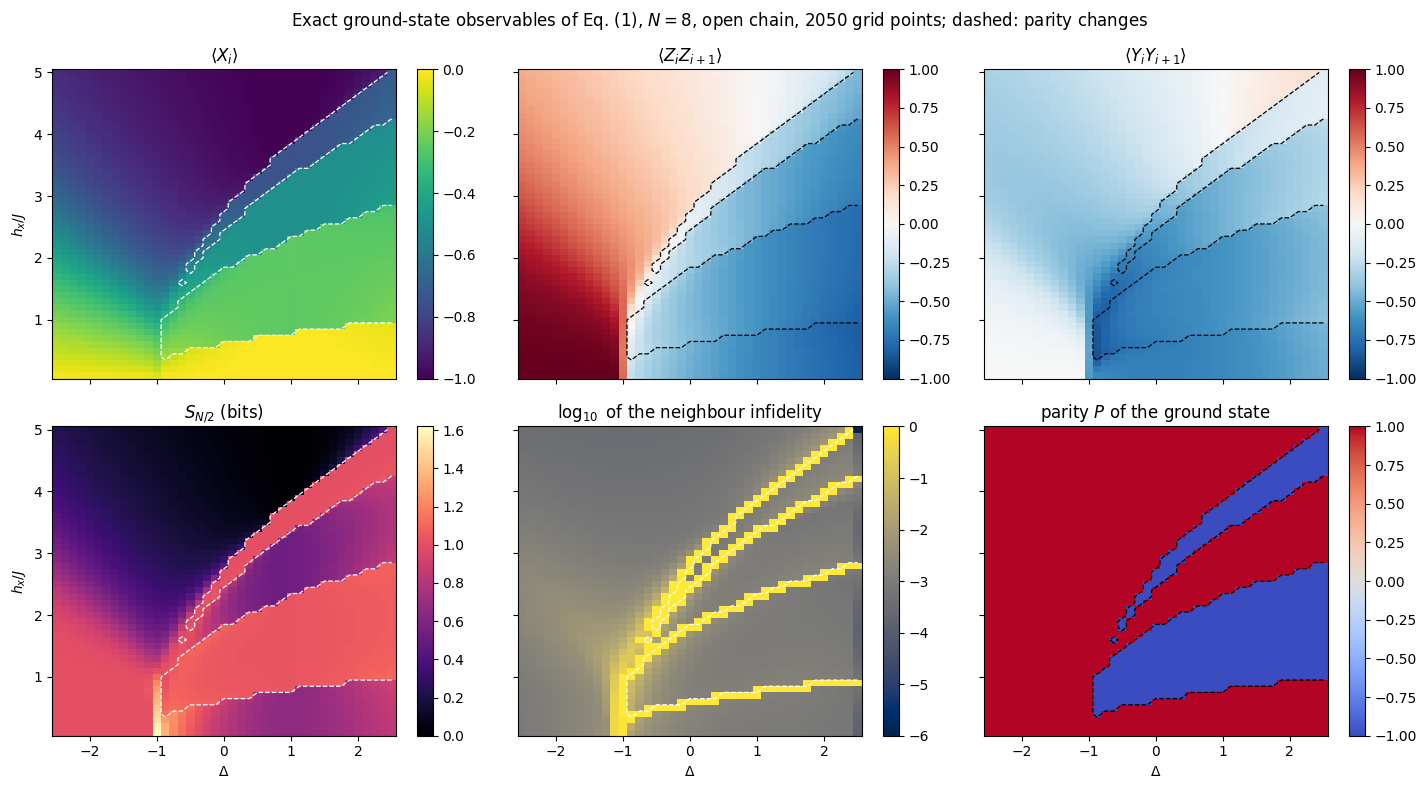

In [6]:
# ==============================================================================
# STEP 3: the reference phase diagram from exact observables
# ==============================================================================
XX_, YY_, ZZ_ = jnp.kron(X, X), jnp.kron(Y, Y), jnp.kron(Z, Z)


def observables(psi):
    """Per-site <X>, nearest-neighbour <ZZ> and <YY> (averaged over the chain), half-chain entropy in bits."""
    mx = jnp.mean(jnp.stack([expect_local(psi, X, (i,)) for i in range(N)]))
    zz = jnp.mean(jnp.stack([expect_local(psi, ZZ_, (i, i + 1)) for i in range(N - 1)]))
    yy = jnp.mean(jnp.stack([expect_local(psi, YY_, (i, i + 1)) for i in range(N - 1)]))
    return mx, zz, yy, entanglement_entropy(psi, tuple(range(N // 2)))


MX, ZZC, YYC, SHALF = [np.asarray(o).reshape(SHAPE) for o in jax.jit(jax.vmap(observables))(PSI_g)]


def overlap2(a, b):
    """|<a|b>|^2 over the last N axes (broadcasts over leading grid axes)."""
    return jnp.abs(jnp.sum(jnp.conj(a) * b, axis=tuple(range(-N, 0)))) ** 2


NB = np.zeros(SHAPE)                                   # neighbour infidelity, max over the right and upper neighbours
NB[:, :-1] = np.maximum(NB[:, :-1], 1 - np.asarray(overlap2(PSI[:, :-1], PSI[:, 1:])))
NB[:-1, :] = np.maximum(NB[:-1, :], 1 - np.asarray(overlap2(PSI[:-1, :], PSI[1:, :])))

for name, (d_, h_) in {"ferromagnetic  (-2.0, 0.3)": (-2.0, 0.3), "Neel           ( 2.0, 0.3)": (2.0, 0.3),
                       "middle band    ( 0.0, 1.0)": (0.0, 1.0), "large field    (-2.0, 4.5)": (-2.0, 4.5)}.items():
    i, j = grid_index(d_, h_)
    print(f"{name}:  <X> = {MX[i, j]:+.3f}   <ZZ> = {ZZC[i, j]:+.3f}   <YY> = {YYC[i, j]:+.3f}   "
          f"S_half = {SHALF[i, j]:.3f} bits   P = {PARITY[i, j]:+.0f}")

# a dense check of the sharp line at Delta = -1, h_x = 0.3: level crossing or avoided crossing
print("\nalong h_x = 0.3: gap to the second level of the EVEN sector (dense), and the neighbour infidelity")
P_dense = np.asarray(jax.vmap(apply_parity)(jnp.eye(2 ** N, dtype=RDTYPE).reshape((2 ** N,) + (2,) * N)).reshape(2 ** N, -1))
w_P, V_P = np.linalg.eigh(P_dense)
B_even = V_P[:, w_P > 0]                                 # orthonormal basis of the P = +1 sector (128 vectors)
for d_ in (-1.25, -1.125, -1.0, -0.875, -0.75):
    we = np.linalg.eigvalsh(B_even.T @ np.real(np.asarray(dense_hamiltonian(terms_at(d_, 0.3), N))) @ B_even)
    i, j = grid_index(d_, 0.3)
    print(f"  Delta = {d_:+.3f}:  E1 - E0 in the even sector = {we[1] - we[0]:.4f}   neighbour infidelity "
          f"(to Delta + 0.125) = {1 - float(overlap2(PSI[i, j], PSI[i, j + 1])):.3f}")

# the parity crossings along three lines of constant Delta, against the classical line of Section 3.1
print("\nparity changes of the ground state along lines of constant Delta (midpoints of the grid intervals):")
for d_ in (-2.0, 0.0, 2.0):
    col = PARITY[:, grid_index(d_, 0.1)[1]]
    x_par = HXS[:-1][np.diff(col) != 0] + 0.05
    h_cl = f"{2 * J * np.sqrt(2 * (1 + d_)):.2f}" if d_ > -1 else "none"
    print(f"  Delta = {d_:+.1f}: {len(x_par)} changes, at h_x = {', '.join(f'{x:.2f}' for x in x_par) or '-'};"
          f"  classical line h_x^cl = {h_cl}")


def draw_parity_lines(ax, color="w"):
    """Dashed contour where the parity of the ground state changes (level crossings of the finite chain)."""
    ax.contour(DELTAS, HXS, PARITY, levels=[0.0], colors=color, linewidths=0.9, linestyles="--")


fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.0), sharex=True, sharey=True)
panels = [(MX, r"$\langle X_i\rangle$", "viridis", None), (ZZC, r"$\langle Z_iZ_{i+1}\rangle$", "RdBu_r", (-1, 1)),
          (YYC, r"$\langle Y_iY_{i+1}\rangle$", "RdBu_r", (-1, 1)), (SHALF, r"$S_{N/2}$ (bits)", "magma", None),
          (np.log10(np.maximum(NB, 1e-8)), r"$\log_{10}$ of the neighbour infidelity", "cividis", (-6, 0)),
          (PARITY, r"parity $P$ of the ground state", "coolwarm", (-1, 1))]
for ax, (data, title, cmap, lim) in zip(axes.flat, panels):
    kw = {} if lim is None else {"vmin": lim[0], "vmax": lim[1]}
    im = ax.pcolormesh(DELTAS, HXS, data, shading="nearest", cmap=cmap, **kw)
    draw_parity_lines(ax, "k" if cmap in ("RdBu_r", "coolwarm") else "w")
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.grid(False)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$h_x/J$")
for ax in axes[1, :]:
    ax.set_xlabel(r"$\Delta$")
fig.suptitle(f"Exact ground-state observables of Eq. (1), $N={N}$, open chain, {n_pts} grid points; dashed: parity changes")
fig.tight_layout(); plt.show()

The six panels divide the plane into four regions; the printed lines give one representative point of each. The
dashed lines, drawn on every panel, mark the places where the parity of the ground state changes.

* **Ferromagnetic** ($\Delta\lesssim-1$, small field): $\langle Z_iZ_{i+1}\rangle=+0.996$ and $S_{N/2}=1.000$ bit at
  $(-2,0.3)$. The state is close to the even combination of $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, which
  carries exactly one bit of entanglement across any cut.
* **Large field** (upper part of the plane, above the highest dashed line and, for $\Delta\lesssim-1$, above the
  ferromagnetic region): $\langle X_i\rangle$ moves towards $-1$ as $h_x$ grows. At the point $(-2,4.5)$
  $\langle X_i\rangle=-0.884$ and $S_{N/2}=0.224$ bits, while the nearest-neighbour correlations
  $\langle Z_iZ_{i+1}\rangle=+0.362$ are still sizeable. Between this region and the ferromagnetic one neither the
  neighbour infidelity nor the parity marks a line: the correlations fade gradually. In the infinite chain the two
  are separated by the order–disorder transition at $h_c\approx2.55J$ ($\Delta=-2$); at $N=8$ there is only a smooth
  crossover, and Section 6.4 shows how its finite-size precursors locate the transition.
* **Small-field antiferromagnetic region** ($\Delta\gtrsim-1$, below the lowest dashed line):
  $\langle Z_iZ_{i+1}\rangle<0$, $\langle X_i\rangle\approx0$. No map shows a feature at $\Delta=1$, where the infinite
  chain has its Kosterlitz–Thouless transition at $h_x=0$ and a gapless line between Néel order along $z$ and along
  $y$ at small $h_x>0$.
* **Middle band** (between the lowest and the highest dashed line): the parity of the ground state alternates from
  one dashed line to the next, and $\langle Y_iY_{i+1}\rangle$ is strongly negative ($-0.673$ at $(0,1)$), i.e.
  antiferromagnetic correlations along $y$, the axis perpendicular to both the field and the anisotropy axis.

The sharp features are of two kinds. Every dashed line is a **level crossing** between the two parity sectors: the
ground state changes discontinuously, and since states of opposite parity are orthogonal the neighbour infidelity is
exactly one there. The line at $\Delta\approx-1$ for small fields has no parity change. The dense check shows what it
is: the gap to the second level of the even sector falls from $0.87$ at $\Delta=-1.25$ to $0.043$ at $\Delta=-1$
($h_x=0.3$), a **narrowly avoided crossing**, and the neighbour infidelities across the two grid intervals around
$\Delta=-1$ are $0.436$ and $0.733$. A smooth crossover, such as the one between the ferromagnetic and large-field
regions, leaves no sharp line, only a faint brightening of the neighbour infidelity (at most $0.004$ along
$\Delta=-2$, Section 6.4). These three kinds of behaviour are the reference against which the anomaly maps are judged.

**The finite chain and the infinite chain.** The sharp lines of the finite chain are not the phase boundaries of
Section 3.1. All three ordered phases of the infinite chain break the spin-flip symmetry ($P$ reverses
$Y_i$ and $Z_i$, and with them the Néel and ferromagnetic order parameters), so their ground state is a doublet of
one even and one odd state. On a finite chain the two members are split, and Dmitriev *et al.* observed, on periodic
chains of 10 to 18 sites, that the two lowest levels cross $N/2$ times as the field grows, the last crossing on the
classical line. Our open chain behaves in the same way (last printed lines): along $\Delta=0$ the eight-site chain
has four parity crossings, the last between $h_x=2.7J$ and $2.8J$, just below $h_x^{\rm cl}=2\sqrt2J\approx2.83J$;
along $\Delta=2$ it has four as well, the last between $4.6J$ and $4.7J$, below $h_x^{\rm cl}=2\sqrt6J\approx4.90J$;
along $\Delta=-2$, where the classical line does not exist, it has none, and neither do chains of $6$ and $10$
sites. Along $\Delta=0$ and $\Delta=2$ chains of $6$ and $10$ sites have three and five crossings, and the lowest one
moves to smaller fields as $N$ grows (Exercise 6). The parity crossings are therefore finite-size features inside
the ordered phases and mark no transition; in the infinite chain they merge into the degenerate doublet. The avoided
crossing at $\Delta\approx-1$, by contrast, is the finite-size image of the boundary between the ferromagnetic phase
and the phase with Néel order along $y$. The order–disorder line $h_c(\Delta)$ and the gapless line at $\Delta=1$
leave no sharp trace at $N=8$. For $\Delta<-1$ the order–disorder transition is the only feature of a line of
increasing field, free of parity crossings; for $\Delta\gtrsim0$ it lies just above the last parity crossing
($h_c\approx2.91J$ against $2.83J$ at $\Delta=0$, both near $5J$ at $\Delta=2$) and cannot be told apart from it at
$N=8$. This is why Section 6.4 follows the transition along $\Delta=-2$.

## 4. The anomaly score of a frozen autoencoder

### 4.1 The encoder and the trash register

The encoder $U(\boldsymbol\theta)$ is the hardware-efficient ansatz of notebooks 40 and 45 applied to the input
state: $L$ layers of [$R_y$ and $R_z$ on every qubit, then a chain of $CZ$ gates], and a final rotation block, with
$n=2N(L+1)$ angles. A set $T$ of $k$ qubits is declared the trash register. We place the trash at the two ends of
the chain ($k=2$: qubits $0$ and $7$); Exercise 4 compares this choice with two adjacent trash qubits at one end.
Kottmann *et al.* used a different circuit, with $R_y$ rotations only and $CZ$ gates between trash and non-trash
qubits and among the trash qubits; the inequalities derived below hold for any encoder.

![The quantum autoencoder of this notebook and its use for anomaly detection: (a) encoder U(theta) on eight qubits, trash qubits 0 and 7 discarded and replaced by fresh zeros, decoder U-dagger(theta); (b) training of the encoder on the reference ground state by the local cost of the trash qubits; (c) the frozen encoder applied to the ground state at every grid point, with the same cost as anomaly score](figures/qae_anomaly_detection.svg)\
**Figure 1.** (a) The quantum autoencoder of notebook 45 at $N=8$ with the trash register $T=\{0,7\}$, $k=2$: the
encoder $U(\boldsymbol\theta)$ maps the input to a state whose trash qubits are close to $\vert0\rangle$; they are
discarded and replaced by fresh $\vert0\rangle$'s, and the decoder $U^\dagger(\boldsymbol\theta)$ rebuilds the input from
the six latent qubits. (b) Training needs only the encoder: the trash qubits are measured and Adam lowers their local
cost $D_H$, Eq. (4), on the reference ground state $\vert\psi_0(\lambda_\star)\rangle$ to $10^{-3}$ or below
(Section 5.3).
(c) Anomaly detection: the trained encoder $U(\boldsymbol\theta_\star)$ is kept fixed and applied to the ground state
at every point of the $(\Delta,h_x)$ grid; the same local cost is the anomaly score of Eq. (8). The latent qubits are
never measured and the decoder is never run.

Write the encoded state in the computational basis of the trash register,

$$U(\boldsymbol\theta)\vert\psi\rangle=\sum_{t\in\{0,1\}^k}\vert\alpha_t\rangle_L\otimes\vert t\rangle_T,\qquad
  p(t)=\lVert\alpha_t\rVert^2,\qquad \sum_tp(t)=1 .\tag{3}$$

A $Z$ measurement of the $k$ trash qubits returns the string $t$ with probability $p(t)$. Let $w(t)$ be its
**Hamming weight**, the number of ones.

### 4.2 Two costs on the same measurement record

The **local cost** of the anomaly-detection protocol is the mean excitation of the trash qubits,

$$D_H=\frac1k\sum_{j\in T}\langle n_j\rangle=\frac1k\sum_{j\in T}\frac{1-\langle Z_j\rangle}2
  =\frac{1}{k}\sum_tp(t)\,w(t),\tag{4}$$

where $n_j=(1-Z_j)/2$ is the projector on $\vert1\rangle$ of qubit $j$; the last form holds because $\sum_jn_j$ is
diagonal in the computational basis with eigenvalue $w(t)$ on $\vert t\rangle$. Kottmann *et al.* use the average
Hamming distance $\sum_j(1-\langle Z_j\rangle)/2=kD_H$; the factor $1/k$ only puts $D_H$ in $[0,1]$. The **global
cost** is the trash infidelity of notebook 45, Eq. (4),

$$1-p_0=1-p(0\cdots0)=\sum_tp(t)\,[\,w(t)>0\,] ,\tag{5}$$

the probability that at least one trash qubit is found in $\vert1\rangle$. Both are averages of a function of $w(t)$
over the same distribution, and for every string $t$

$$\frac{w(t)}{k}\;\le\;[\,w(t)>0\,]\;\le\;w(t),$$

because $0\le w(t)\le k$ and $w(t)\ge1$ whenever it is non-zero. Averaging over $p(t)$ gives

$$D_H\;\le\;1-p_0\;\le\;k\,D_H .\tag{6}$$

The right inequality is the union bound: the probability that some trash qubit is excited is at most the sum of the
probabilities for each of them. Equation (6) says that the two costs vanish together and differ by at most a factor
$k$. Notebook 45, Eq. (9), bounded the reconstruction fidelity of the full autoencoder (encode, reset the trash,
decode) by the trash fidelity, $F_{\rm rec}\ge p_0^2$; combined with Eq. (6),

$$F_{\rm rec}\;\ge\;p_0^2\;\ge\;\bigl(1-kD_H\bigr)^2\qquad(kD_H\le1),\tag{7}$$

so a small local cost guarantees a faithful reconstruction, and the decoder never needs to be run.

### 4.3 The anomaly map, and what bounds it

Let $\lambda=(\Delta,h_x)$, let $\vert\psi_0(\lambda)\rangle$ be the ground state, and let $\boldsymbol\theta_\star$ be
the angles obtained by training on the single state $\vert\psi_\star\rangle=\vert\psi_0(\lambda_\star)\rangle$ at a
**reference point** $\lambda_\star$. The **anomaly map** is the local cost of the frozen encoder on every other ground
state,

$$\mathcal A_k(\lambda\,\vert\,\lambda_\star)=D_H\bigl(U(\boldsymbol\theta_\star)\vert\psi_0(\lambda)\rangle\bigr) .\tag{8}$$

No retraining happens during the scan; one forward pass of the circuit per grid point suffices.

To see what Eq. (8) measures, let $\Pi=\mathbb 1_L\otimes\vert0\cdots0\rangle\langle0\cdots0\vert_T$ and
$Q=U^\dagger\Pi U$, the projector onto the $2^{N-k}$-dimensional subspace of inputs that the encoder compresses
perfectly. Then $p_0(\psi)=\langle\psi\vert Q\vert\psi\rangle=\lVert Q\psi\rVert^2$, and training leaves a residual
$\varepsilon=1-p_0(\psi_\star)=\lVert(1-Q)\psi_\star\rVert^2$ at the reference. For any other input, the Cauchy–Schwarz
inequality with the unit vector $\psi_\star$, followed by the triangle inequality, gives

$$\lVert Q\psi\rVert\ \ge\ \bigl\vert\langle\psi_\star\vert Q\psi\rangle\bigr\vert
  =\bigl\vert\langle\psi_\star\vert\psi\rangle-\langle(1-Q)\psi_\star\vert\psi\rangle\bigr\vert
  \ \ge\ \bigl\vert\langle\psi_\star\vert\psi\rangle\bigr\vert-\sqrt\varepsilon .$$

With the left half of Eq. (6),

$$\mathcal A_k(\lambda\,\vert\,\lambda_\star)\ \le\ 1-p_0\ \le\
  1-\Bigl(\max\bigl\{0,\ \vert\langle\psi_\star\vert\psi_0(\lambda)\rangle\vert-\sqrt\varepsilon\bigr\}\Bigr)^2 .\tag{9}$$

A well-trained encoder therefore cannot flag a state that has a large overlap with the training state: **the anomaly
score is bounded above by the infidelity with the reference state**. There is no bound in the other direction.
$Q$ projects on a subspace of dimension $2^{N-k}$ (64 for $k=2$), of which training fixes only one direction, so a
state orthogonal to $\psi_\star$ may still be compressed. How large the region of small scores is, and where it ends,
depends on the remaining $2^{N-k}-1$ directions, which training does not control. Section 6 measures it.

### 4.4 The identity encoder scores exactly one half

With all angles zero, $R_y(0)=R_z(0)=\mathbb 1$ and the $CZ$ chain is diagonal, so $p(t)$ is the distribution of the
trash bits in the input itself and $\langle Z_j\rangle$ is evaluated on $\psi_0(\lambda)$. Every ground state on the
grid has definite parity, $P\vert\psi_0\rangle=\pm\vert\psi_0\rangle$, and $PZ_jP=-Z_j$, so

$$\langle Z_j\rangle=\langle\psi_0\vert P\,Z_j\,P\vert\psi_0\rangle=-\langle Z_j\rangle=0
  \qquad\Longrightarrow\qquad D_H(\boldsymbol\theta=0)=\tfrac12\ \ \text{on every ground state.}\tag{10}$$

The untrained identity encoder produces a perfectly flat map. This is the first control: whatever structure a map
has is produced by the encoder angles.

In [7]:
# ==============================================================================
# STEP 4: encoder, trash costs, and the checks of Eqs. (6) and (10)
# ==============================================================================
# PARAMETERS
LAYERS = 4                                            # encoder depth L; n = 2N(L+1) angles
TRASH = {1: (N - 1,), 2: (0, N - 1), 3: (0, N - 2, N - 1), 4: (0, 1, N - 2, N - 1)}   # trash at the chain ends
N_PAR = hea_num_params(N, LAYERS)


def rot_block(psi, row):
    """One rotation block: Ry(theta) then Rz(theta) on every qubit."""
    for q in range(N):
        psi = apply_gate(psi, ry(row[q, 0]), [q])
        psi = apply_gate(psi, rz(row[q, 1]), [q])
    return psi


def ent_block(psi):
    """One entangling block: a chain of CZ gates on the nearest-neighbour bonds."""
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    return psi


def encode(theta, psi, layers=LAYERS):
    """Encoder U(theta)|psi>: the hardware-efficient ansatz applied to an ARBITRARY input state.

    MATH  U(theta) = R(theta_L) prod_{l<L} [ ENT . R(theta_l) ],  R = prod_q Rz(.) Ry(.),  ENT = chain of CZ.
    JAX   the L repeated layers are a `lax.scan` over the rows of theta, so the traced graph does not grow with L.
    """
    th = theta.reshape(layers + 1, N, 2)
    psi, _ = lax.scan(lambda p, row: (ent_block(rot_block(p, row)), None), psi, th[:layers])
    return rot_block(psi, th[layers])


# BITS[t, q] = value of qubit q in the basis string t (C order: qubit 0 is the most significant bit)
BITS = jnp.asarray((np.arange(2 ** N)[:, None] >> (N - 1 - np.arange(N))[None, :]) & 1, dtype=RDTYPE)


def trash_mask(k):
    """0/1 vector of length N marking the k trash qubits of TRASH[k]."""
    return jnp.asarray([1.0 if q in TRASH[k] else 0.0 for q in range(N)], dtype=RDTYPE)


def trash_costs(phi, mask):
    """(D_H, 1 - p_0) of an encoded state phi, for the trash qubits marked by `mask`.

    MATH   p(t) = |phi_t|^2 is the Born distribution of basis strings; w(t) = sum_{q in T} t_q is the Hamming
           weight of the trash bits of t.  Then  D_H = E_p[w]/k  (Eq. (4)),  1 - p_0 = P_p[w > 0]  (Eq. (5)).
    IMPLEMENTATION  w for all 2^N strings is ONE matrix-vector product BITS @ mask; "all trash bits zero" is
           prod_q (1 - mask_q t_q).  The mask is a traced array, so the trash register can change without
           recompiling.
    COST   O(N 2^N).
    """
    p = jnp.abs(phi.reshape(-1)) ** 2
    k = jnp.sum(mask)
    d_h = p @ (BITS @ mask) / k
    p0 = p @ jnp.prod(1.0 - BITS * mask[None, :], axis=1)
    return d_h, 1.0 - p0


# --- CHECKPOINT: the encoder reproduces the engine ansatz ------------------------------------------------
th_chk = jax.random.uniform(jax.random.PRNGKey(1), (N_PAR,), minval=-jnp.pi, maxval=jnp.pi)
err_hea = max_abs(encode(th_chk, zero_state(N)) - hardware_efficient_ansatz(th_chk, N, LAYERS))
print(f"encode(theta, |0..0>) vs the engine's hardware_efficient_ansatz : {err_hea:.2e}")
assert err_hea < TOL

# --- CHECKPOINT: trash_costs against reduced density matrices --------------------------------------------
phi_chk = encode(th_chk, PSI[grid_index(0.0, 1.0)])
for k in (1, 2, 3, 4):
    d_h, g = trash_costs(phi_chk, trash_mask(k))
    n1 = np.mean([float(jnp.real(rdm(phi_chk, (q,))[1, 1])) for q in TRASH[k]])   # <n_q> = <1|rho_q|1>
    p0 = float(jnp.real(rdm(phi_chk, TRASH[k])[0, 0]))                              # <0..0|rho_T|0..0>
    print(f"  k = {k}, trash {str(TRASH[k]):13s}  D_H = {float(d_h):.10f} (rdm {n1:.10f})   "
          f"1 - p0 = {float(g):.10f} (rdm {1 - p0:.10f})")
    assert abs(float(d_h) - n1) < TOL and abs(float(g) - (1 - p0)) < TOL

# --- CHECKPOINT: Eq. (6) for 2000 random encoders applied to random grid states -----------------------------
th_r = jax.random.uniform(jax.random.PRNGKey(2), (2000, N_PAR), minval=-jnp.pi, maxval=jnp.pi)
idx_r = jax.random.randint(jax.random.PRNGKey(3), (2000,), 0, n_pts)
for k in (2, 3, 4):
    dh_r, g_r = jax.jit(jax.vmap(lambda t, i: trash_costs(encode(t, PSI_g[i]), trash_mask(k))))(th_r, idx_r)
    dh_r, g_r = np.asarray(dh_r), np.asarray(g_r)
    print(f"  k = {k}: violations of D_H <= 1-p0: {int(np.sum(dh_r > g_r + 1e-12))},  of 1-p0 <= k D_H: "
          f"{int(np.sum(g_r > k * dh_r + 1e-12))}  (2000 pairs);  ratio (1-p0)/D_H in "
          f"[{(g_r / dh_r).min():.3f}, {(g_r / dh_r).max():.3f}]")
    assert np.all(dh_r <= g_r + 1e-12) and np.all(g_r <= k * dh_r + 1e-12)

# --- CHECKPOINT: Eq. (10), the identity encoder scores exactly 1/2 on every ground state ----------------------
dh_id = jax.vmap(lambda p: trash_costs(p, trash_mask(2))[0])(PSI_g)
print(f"identity encoder (all angles zero), k = 2: D_H over the {n_pts} ground states in "
      f"[{float(dh_id.min()):.12f}, {float(dh_id.max()):.12f}]")
assert max_abs(dh_id - 0.5) < 1e-8

encode(theta, |0..0>) vs the engine's hardware_efficient_ansatz : 0.00e+00


  k = 1, trash (7,)           D_H = 0.2832491914 (rdm 0.2832491914)   1 - p0 = 0.2832491914 (rdm 0.2832491914)
  k = 2, trash (0, 7)         D_H = 0.3511597109 (rdm 0.3511597109)   1 - p0 = 0.5865848133 (rdm 0.5865848133)


  k = 3, trash (0, 6, 7)      D_H = 0.3816996130 (rdm 0.3816996130)   1 - p0 = 0.7572091974 (rdm 0.7572091974)
  k = 4, trash (0, 1, 6, 7)   D_H = 0.4041736570 (rdm 0.4041736570)   1 - p0 = 0.8952451627 (rdm 0.8952451627)


  k = 2: violations of D_H <= 1-p0: 0,  of 1-p0 <= k D_H: 0  (2000 pairs);  ratio (1-p0)/D_H in [1.151, 1.935]


  k = 3: violations of D_H <= 1-p0: 0,  of 1-p0 <= k D_H: 0  (2000 pairs);  ratio (1-p0)/D_H in [1.184, 2.767]


  k = 4: violations of D_H <= 1-p0: 0,  of 1-p0 <= k D_H: 0  (2000 pairs);  ratio (1-p0)/D_H in [1.229, 3.287]


identity encoder (all angles zero), k = 2: D_H over the 2050 ground states in [0.500000000000, 0.500000000000]


`trash_costs` agrees with the reduced density matrices of the trash qubits to ten digits for every $k$. Equation (6)
holds for all 6000 random encoder–state pairs, with the ratio $(1-p_0)/D_H$ between $1.15$ and $3.29$; Exercise 1
shows that both bounds are attained by suitable states. The identity encoder returns $1/2$ on all 2050 ground states,
as Eq. (10) requires.

### 4.5 Local and global cost at random initialisation

For $k=1$ the two costs of Eqs. (4) and (5) are the same function. For $k>1$ the global cost asks whether *all*
trash qubits are in $\vert0\rangle$ at once: in the language of notebook 40, Section 5.3, it is a global cost on the
trash register, while $D_H$ is a sum of single-qubit terms. Cerezo, Sone, Volkoff, Cincio and Coles (2021) proved
for a class of layered circuits that global costs have gradients whose variance vanishes exponentially with the
number of qubits the cost acts on, already at shallow depth, while local costs keep a variance that decays at worst
polynomially when the depth grows at most logarithmically; they used the quantum autoencoder as an example.
Kottmann *et al.* chose the local Hamming cost for this reason. Notebook 40, Section 13, measured the two
behaviours for the hardware-efficient ansatz as a function of $N$. Here the global cost acts on at most four qubits,
and the question is only how large the difference is at the sizes we use. We draw 400 random angle vectors, compute
the gradients of both costs with `jax.grad`, and take the variance of each component over the draws, averaged over
the 80 components. The statistical error is estimated from eight disjoint batches of 50 draws.

In [8]:
# ==============================================================================
# STEP 5: variance of the gradient at random initialisation, local against global cost
# ==============================================================================
# PARAMETERS
R_GRAD = 400                                          # random parameter draws per configuration (8 batches of 50)
REF_GRAD = (2.0, 0.3)                                 # the input state (any ground state would do)

psi_gr = PSI[grid_index(*REF_GRAD)]
th_g = jax.random.uniform(jax.random.PRNGKey(4), (R_GRAD, N_PAR), minval=-jnp.pi, maxval=jnp.pi)
grad_both = jax.jit(jax.vmap(lambda t, m: jnp.stack([jax.grad(lambda x: trash_costs(encode(x, psi_gr), m)[c])(t)
                                                     for c in (0, 1)]), in_axes=(0, None)))
print(f"variance of a gradient component over {R_GRAD} uniform draws, averaged over the {N_PAR} components")
print(f"{'k':>3s} {'Var(dD_H)':>11s} {'Var(d(1-p0))':>13s} {'ratio global/local':>25s}")
VAR_RATIO = {}
for k in (1, 2, 3, 4):
    G = np.asarray(grad_both(th_g, trash_mask(k)))                        # (R_GRAD, 2, N_PAR)
    v_loc, v_glo = G[:, 0].var(axis=0).mean(), G[:, 1].var(axis=0).mean()
    batches = G.reshape(8, R_GRAD // 8, 2, N_PAR).var(axis=1).mean(axis=-1)   # (8, 2)
    r_mean, r_se = mean_and_se(batches[:, 1] / batches[:, 0])
    VAR_RATIO[k] = (r_mean, r_se)
    print(f"{k:3d} {v_loc:11.3e} {v_glo:13.3e} {v_glo / v_loc:12.3f}  (batches {r_mean:.3f} +- {r_se:.3f})")
    if k == 1:
        assert abs(v_loc - v_glo) < 1e-12                                 # k = 1: the same cost function

variance of a gradient component over 400 uniform draws, averaged over the 80 components
  k   Var(dD_H)  Var(d(1-p0))        ratio global/local


  1   2.199e-03     2.199e-03        1.000  (batches 1.000 +- 0.000)


  2   1.092e-03     1.166e-03        1.068  (batches 1.069 +- 0.022)


  3   6.666e-04     6.260e-04        0.939  (batches 0.941 +- 0.020)


  4   4.604e-04     2.550e-04        0.554  (batches 0.553 +- 0.017)


For $k=1$ the two costs are the same function and the variances agree exactly. At $k=2$ and $k=3$ the gradient
variances of the two costs agree within $7\,\%$; at $k=4$ the global cost has the smaller variance, by a factor
$0.55\pm0.02$. At these sizes local and global cost differ by at most a factor of two in gradient variance. The
exponential separation proved by Cerezo *et al.* concerns how the variance scales with the number of qubits the
observable acts on, and four trash qubits are too few to display it. The reasons to use $D_H$ here are therefore its
favourable scaling, its direct measurement as a mean of single-qubit outcomes, and Eq. (7), which makes it as strict a
criterion of compression as the global cost. Whether either cost trains better at $N=8$ is measured next.

## 5. Training at a reference point

### 5.1 A training loop shared by every experiment

Training minimises Eq. (4) (or Eq. (5)) for one input state with Adam (notebook 41, Section 6), as a `lax.scan`
over iterations. Both costs are recorded at every iteration, whichever one is being minimised, so that every run is
judged by the same criterion. We call a run **successful** if it ends with $1-p_0<10^{-2}$, and report the success
fraction with its 68 % Wilson interval (notebook 41, Section 12); by Eq. (7) the
reconstruction fidelity of such an encoder is at least $0.98$. Each argument of the training function — start
angles, input state, trash mask, cost selector, step size — is an array with a batch dimension, so a whole study
is one `vmap`.

### 5.2 Choosing the step size for both costs

A comparison of two costs is only meaningful if each runs at a step size that suits it (notebook 41, Section 11).
We bracket three step sizes, $\eta\in\{0.03,0.1,0.3\}$, for each cost, with the same eight random starts, the same
budget of 300 iterations, and the same success criterion, at the Néel reference point $(\Delta,h_x)=(2,0.3)$.

In [9]:
# ==============================================================================
# STEP 6: the training loop, and a step-size bracket for both costs under the same budget
# ==============================================================================
# PARAMETERS
N_STEPS = 300                                          # Adam iterations per run
LRS = (0.03, 0.1, 0.3)                                 # step sizes bracketed for each cost
R_TUNE = 8                                             # random starts per (cost, step size)
SUCCESS = 0.01                                         # success: global trash infidelity 1 - p0 below 1 %
REF_TUNE = (2.0, 0.3)


def train_run(theta0, psi, mask, use_global, lr):
    """One Adam run on the trash cost of a single input state, compiled as a `lax.scan`.

    The cost is D_H (use_global = 0) or 1 - p_0 (use_global = 1); BOTH are recorded at every step.
    lr, mask and use_global are traced, so runs that differ in them share one compiled program.
    Returns (final angles, history of (D_H, 1 - p_0) with shape (N_STEPS, 2)).
    """
    def cost(th):
        d_h, g = trash_costs(encode(th, psi), mask)
        return jnp.where(use_global > 0, g, d_h), jnp.stack([d_h, g])

    def body(carry, i):
        th, m, v = carry
        (_, both), grad = jax.value_and_grad(cost, has_aux=True)(th)
        m = 0.9 * m + 0.1 * grad                                           # Adam moments (notebook 41)
        v = 0.999 * v + 0.001 * grad ** 2
        th = th - lr * (m / (1 - 0.9 ** i)) / (jnp.sqrt(v / (1 - 0.999 ** i)) + 1e-8)
        return (th, m, v), both                                            # `both` belongs to the angles BEFORE the step

    z = jnp.zeros_like(theta0)
    (th, _, _), hist = lax.scan(body, (theta0, z, z), jnp.arange(1, N_STEPS + 1))
    return th, hist


train_batch = jax.jit(jax.vmap(train_run))             # every argument batched: starts, states, masks, costs, steps


def random_starts(n, seed):
    """n angle vectors drawn uniformly from [-pi, pi]^N_PAR."""
    return jax.random.uniform(jax.random.PRNGKey(seed), (n, N_PAR), minval=-jnp.pi, maxval=jnp.pi)


# one batch: 2 costs x 3 step sizes x R_TUNE starts, all on the same state and from the same starting angles
psi_t = PSI[grid_index(*REF_TUNE)]
th0 = random_starts(R_TUNE, seed=10)
cfg = [(c, lr) for c in (0, 1) for lr in LRS]
B = len(cfg) * R_TUNE
args = (jnp.tile(th0, (len(cfg), 1)), jnp.broadcast_to(psi_t, (B,) + psi_t.shape),
        jnp.broadcast_to(trash_mask(2), (B, N)),
        jnp.repeat(jnp.asarray([c for c, _ in cfg], dtype=RDTYPE), R_TUNE),
        jnp.repeat(jnp.asarray([lr for _, lr in cfg], dtype=RDTYPE), R_TUNE))
t0 = time.perf_counter()
tune_compiled = train_batch.lower(*args).compile()
t1 = time.perf_counter()
_, H_TUNE = jax.block_until_ready(tune_compiled(*args))
t2 = time.perf_counter()
H_TUNE = np.asarray(H_TUNE).reshape(len(cfg), R_TUNE, N_STEPS, 2)
print(f"{B} runs x {N_STEPS} iterations (N = {N}, L = {LAYERS}, k = 2, {N_PAR} angles): compilation {t1 - t0:.1f} s,"
      f" execution {t2 - t1:.1f} s ({1e3 * (t2 - t1) / (B * N_STEPS):.2f} ms per run and iteration)")
print(f"\n{'cost':>8s} {'lr':>5s} {'success':>8s} {'68% Wilson':>13s} {'median 1-p0':>12s} {'median D_H':>11s} "
      f"{'first iteration with 1-p0<0.01 (median)':>41s}")
for c_i, (c, lr) in enumerate(cfg):
    fin = H_TUNE[c_i, :, -1, :]
    s = int(np.sum(fin[:, 1] < SUCCESS))
    lo, hi = wilson_interval(s, R_TUNE)
    hit = [int(np.argmax(h < SUCCESS)) + 1 for h in H_TUNE[c_i, :, :, 1] if np.any(h < SUCCESS)]
    print(f"{['local', 'global'][c]:>8s} {lr:5.2f} {s:4d}/{R_TUNE:<3d} [{lo:.2f}, {hi:.2f}] "
          f"{np.median(fin[:, 1]):12.2e} {np.median(fin[:, 0]):11.2e} {np.median(hit) if hit else float('nan'):41.0f}")

48 runs x 300 iterations (N = 8, L = 4, k = 2, 80 angles): compilation 2.2 s, execution 5.3 s (0.37 ms per run and iteration)

    cost    lr  success    68% Wilson  median 1-p0  median D_H   first iteration with 1-p0<0.01 (median)
   local  0.03    8/8   [0.89, 1.00]     2.93e-03    1.50e-03                                        88
   local  0.10    8/8   [0.89, 1.00]     1.52e-03    7.69e-04                                        60
   local  0.30    8/8   [0.89, 1.00]     1.42e-03    7.18e-04                                        54
  global  0.03    8/8   [0.89, 1.00]     1.88e-03    9.60e-04                                        73
  global  0.10    8/8   [0.89, 1.00]     1.49e-03    7.59e-04                                        59
  global  0.30    8/8   [0.89, 1.00]     1.35e-03    6.88e-04                                        46


Every run with either cost and every step size ends below the threshold: $8/8$ in each of the six configurations, a
success probability in $[0.89,1.00]$ at 68 % confidence. The two costs also behave alike in detail. At equal step size
their median final infidelities agree within a factor $1.6$, and the median iteration at which $1-p_0$ first falls
below $10^{-2}$ differs by at most 15 iterations between the costs (88 against 73 at $\eta=0.03$), while for the same
cost it differs by 34 (local) and 27 (global) iterations between the smallest and the largest step size. At $N=8$ and
$k=2$ the bracket gives no reason to prefer either cost for training. The local one is used from now on, at
$\eta=0.1$; the step sizes $0.1$ and $0.3$ give nearly the same results.

After 300 iterations the median global infidelity is about $1.5\times10^{-3}$: an order of magnitude below the
success threshold, but not zero. The compiled batch of 48 runs takes a few seconds to compile and about a millisecond
or less per run and iteration to execute.

### 5.3 Four reference points

We train on the local cost with $\eta=0.1$ at four reference points, one in each region of Section 3.2: Néel
$(2,0.3)$, ferromagnetic $(-2,0.3)$, the middle band $(0,1)$, whose ground state has $P=-1$, and large field
$(-2,4.5)$. The ferromagnetic and the large-field points lie on the same line $\Delta=-2$, on the two sides of the
order–disorder transition at $h_c\approx2.55J$; Section 6.4 uses them as a pair. Twelve random starts per point give
the success fraction with its Wilson interval.

48 training runs (local cost, k = 2, lr = 0.1) in 5.6 s (a new batch size, so this includes a compilation)

   reference  (Delta, h_x)  success    68% Wilson  best 1-p0  median 1-p0  median D_H
        Neel    (2.0, 0.3)   12/12  [0.92, 1.00]   8.96e-04     1.53e-03    7.83e-04
ferromagnetic   (-2.0, 0.3)   12/12  [0.92, 1.00]   4.52e-06     1.30e-04    6.48e-05
 middle band    (0.0, 1.0)   11/12  [0.80, 0.97]   1.13e-03     2.51e-03    1.26e-03
 large field   (-2.0, 4.5)   12/12  [0.92, 1.00]   8.56e-05     1.33e-04    6.64e-05


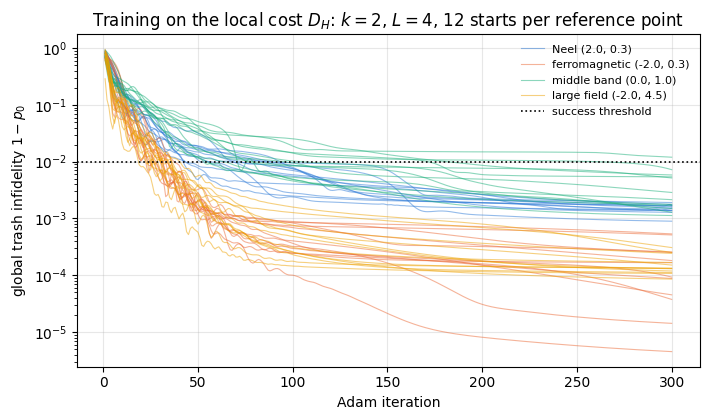

In [10]:
# ==============================================================================
# STEP 7: success statistics at four reference points
# ==============================================================================
# PARAMETERS
LR = 0.1                                               # from the bracket of Step 6
R_RUNS = 12                                            # random starts per reference point
REFS = {"Neel": (2.0, 0.3), "ferromagnetic": (-2.0, 0.3), "middle band": (0.0, 1.0), "large field": (-2.0, 4.5)}

ref_names = list(REFS)
B = len(REFS) * R_RUNS
th0 = random_starts(R_RUNS, seed=20)
psi_refs = jnp.stack([PSI[grid_index(*REFS[n])] for n in ref_names])
t0 = time.perf_counter()
TH_REF, H_REF = jax.block_until_ready(train_batch(
    jnp.tile(th0, (len(REFS), 1)), jnp.repeat(psi_refs, R_RUNS, axis=0), jnp.broadcast_to(trash_mask(2), (B, N)),
    jnp.zeros(B, dtype=RDTYPE), jnp.full(B, LR, dtype=RDTYPE)))
print(f"{B} training runs (local cost, k = 2, lr = {LR}) in {time.perf_counter() - t0:.1f} s "
      f"(a new batch size, so this includes a compilation)")
TH_REF = np.asarray(TH_REF).reshape(len(REFS), R_RUNS, N_PAR)
H_REF = np.asarray(H_REF).reshape(len(REFS), R_RUNS, N_STEPS, 2)
print(f"\n{'reference':>12s} {'(Delta, h_x)':>13s} {'success':>8s} {'68% Wilson':>13s} {'best 1-p0':>10s} "
      f"{'median 1-p0':>12s} {'median D_H':>11s}")
OK_RUNS = {}
for r, name in enumerate(ref_names):
    fin = H_REF[r, :, -1, 1]
    s = int(np.sum(fin < SUCCESS))
    lo, hi = wilson_interval(s, R_RUNS)
    OK_RUNS[name] = np.where(fin < SUCCESS)[0]
    print(f"{name:>12s} {str(REFS[name]):>13s} {s:4d}/{R_RUNS:<3d} [{lo:.2f}, {hi:.2f}] {fin.min():10.2e} "
          f"{np.median(fin):12.2e} {np.median(H_REF[r, :, -1, 0]):11.2e}")
    assert s >= 2                                      # the maps below need at least two trained encoders

fig, ax = plt.subplots(figsize=(7.2, 4.3))
it = np.arange(1, N_STEPS + 1)
for r, name in enumerate(ref_names):
    for run in range(R_RUNS):
        ax.semilogy(it, H_REF[r, run, :, 1], color=PALETTE[r], lw=0.8, alpha=0.5,
                    label=f"{name} {REFS[name]}" if run == 0 else None)
ax.axhline(SUCCESS, color="k", ls=":", lw=1.2, label="success threshold")
ax.set_xlabel("Adam iteration"); ax.set_ylabel(r"global trash infidelity $1-p_0$")
ax.set_title(f"Training on the local cost $D_H$: $k=2$, $L={LAYERS}$, {R_RUNS} starts per reference point")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

All twelve starts succeed at the Néel, ferromagnetic and large-field points, eleven of twelve in the middle band,
where the median final infidelity is also the largest ($2.5\times10^{-3}$). The two points on $\Delta=-2$ train an
order of magnitude better (median $1.3\times10^{-4}$). The curves fall steeply during the first few tens of iterations
and slowly afterwards; no run reaches zero within 300 iterations. The maps of Section 6.1 use the best start at each
point, whose residual is at most $\varepsilon=1.1\times10^{-3}$; in Eq. (9) it enters as $\sqrt\varepsilon\le0.034$,
a small correction to the overlap amplitude.

## 6. Anomaly maps over the phase diagram

### 6.1 Frozen encoders on all ground states

For each reference point the encoder with the lowest final $1-p_0$ is frozen and Eq. (8) is evaluated on all 2050
ground states — one `vmap` over states, nested in a `vmap` over encoders. The first figure shows the four maps, the
second the exact infidelity of every ground state with the reference state,
$1-\vert\langle\psi_\star\vert\psi_0(\lambda)\rangle\vert^2$, in the same arrangement; the code checks Eq. (9) at
every grid point.

4 encoders x 2050 ground states scanned in 1.70 s (compilation included)

   reference  eps=1-p0(ref)  max(A - bound)  A at ref  area A<0.05  area overlap^2>0.95  area P equal to P(ref)


        Neel       8.95e-04       -2.07e-02   4.5e-04        0.180                0.050                   0.746


ferromagnetic       4.51e-06       -4.24e-03   2.3e-06        0.067                0.042                   0.746


 middle band       1.13e-03       -6.54e-02   5.6e-04        0.182                0.059                   0.254


 large field       8.55e-05       -1.84e-02   4.3e-05        0.440                0.192                   0.746

                           mean score over          Neel ferromagnetic   middle band   large field
  ferromagnetic (Delta <= -1.25, h_x <= 1)         0.958         0.012         0.543         0.222
  large field (Delta <= -1.25, h_x >= 3.5)         0.774         0.258         0.113         0.001
                odd-parity points (P = -1)         0.179         0.694         0.056         0.238
Neel encoder along Delta = 2, between successive parity changes: h_x 0.1-0.9: 0.000-0.003;  h_x 1.0-2.6: 0.022-0.051;  h_x 2.7-3.9: 0.177-0.224;  h_x 4.0-4.6: 0.442-0.470;  h_x 4.7-5.0: 0.586-0.606


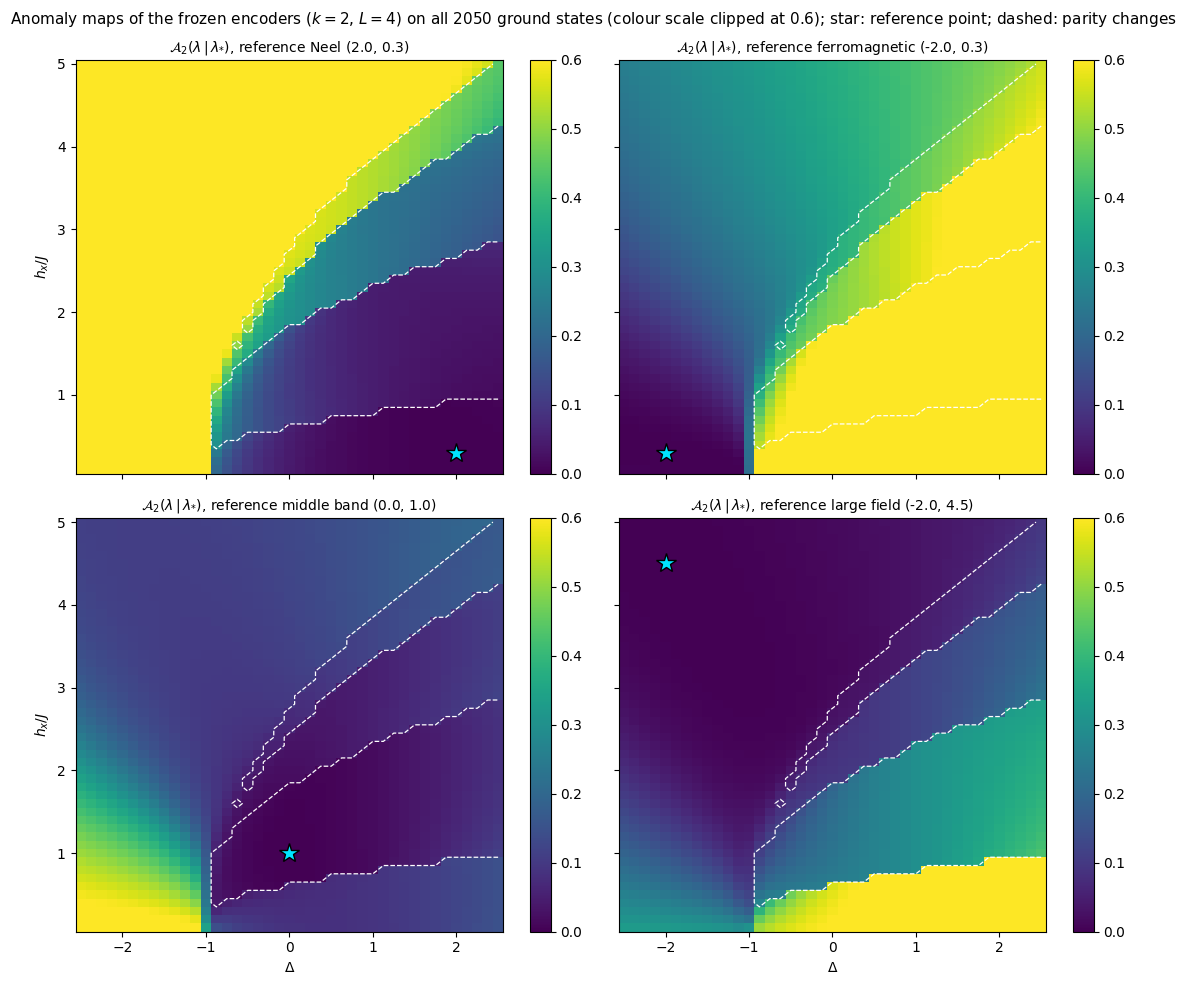

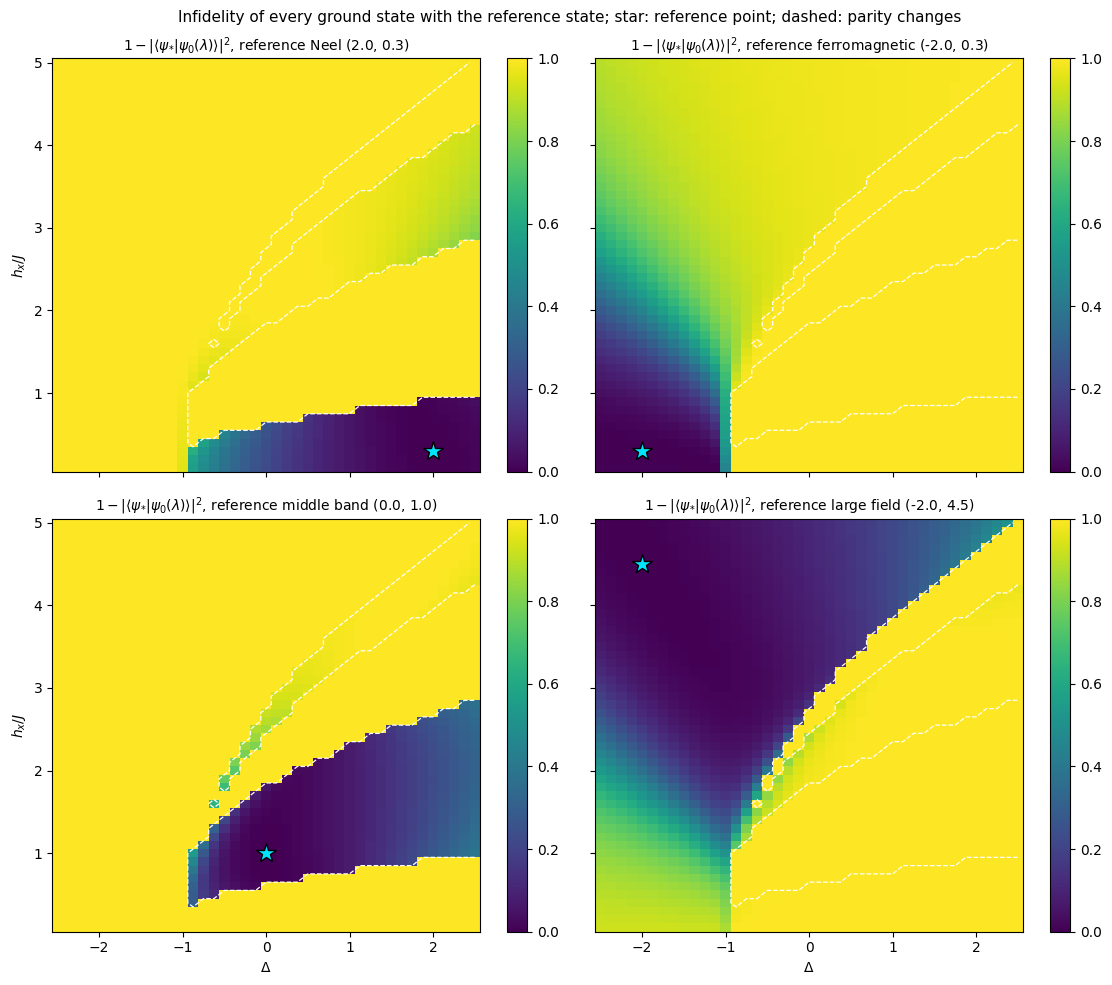

In [11]:
# ==============================================================================
# STEP 8: anomaly maps of the trained encoders over the whole grid, and the bound of Eq. (9)
# ==============================================================================
TAU = 0.05                                             # a grid point with A < TAU counts as "compressed"

anomaly_map = jax.jit(jax.vmap(lambda th, mask: jax.vmap(lambda p: trash_costs(encode(th, p), mask)[0])(PSI_g),
                               in_axes=(0, None)))    # (encoders, N_PAR) x all grid states -> D_H


def best_run(r):
    """Index of the start with the lowest final 1 - p0 at reference r."""
    return int(np.argmin(H_REF[r, :, -1, 1]))


TH_BEST = jnp.asarray(np.stack([TH_REF[r, best_run(r)] for r in range(len(REFS))]))
t0 = time.perf_counter()
A_BEST = np.asarray(jax.block_until_ready(anomaly_map(TH_BEST, trash_mask(2)))).reshape((len(REFS),) + SHAPE)
print(f"{len(REFS)} encoders x {n_pts} ground states scanned in {time.perf_counter() - t0:.2f} s "
      f"(compilation included)")

print(f"\n{'reference':>12s} {'eps=1-p0(ref)':>14s} {'max(A - bound)':>15s} {'A at ref':>9s} "
      f"{'area A<0.05':>12s} {'area overlap^2>0.95':>20s} {'area P equal to P(ref)':>23s}")
OVL = {}
for r, name in enumerate(ref_names):
    i, j = grid_index(*REFS[name])
    eps = float(trash_costs(encode(TH_BEST[r], PSI[i, j]), trash_mask(2))[1])
    amp = np.sqrt(np.asarray(overlap2(PSI[i, j][None, None], PSI)))       # |<psi*|psi(lambda)>|
    OVL[name] = amp ** 2
    bound = 1 - np.maximum(0.0, amp - np.sqrt(eps)) ** 2                  # right-hand side of Eq. (9)
    excess = float(np.max(A_BEST[r] - bound))
    print(f"{name:>12s} {eps:14.2e} {excess:15.2e} {A_BEST[r, i, j]:9.1e} {np.mean(A_BEST[r] < TAU):12.3f} "
          f"{np.mean(amp ** 2 > 0.95):20.3f} {np.mean(PARITY == PARITY[i, j]):23.3f}")
    assert excess < 1e-10                                                  # Eq. (9) at every grid point
    assert np.all(amp[PARITY != PARITY[i, j]] < 1e-8)                      # opposite parity: exactly orthogonal

# mean scores of each encoder over three regions of Section 3.2, and the Neel encoder between the crossings of Delta = 2
REGIONS = {"ferromagnetic (Delta <= -1.25, h_x <= 1)": (DD <= -1.25) & (HH <= 1.0),
           "large field (Delta <= -1.25, h_x >= 3.5)": (DD <= -1.25) & (HH >= 3.5),
           "odd-parity points (P = -1)": PARITY < 0}
print(f"\n{'mean score over':>42s} " + " ".join(f"{n:>13s}" for n in ref_names))
for lab, msk in REGIONS.items():
    print(f"{lab:>42s} " + " ".join(f"{A_BEST[r][msk].mean():13.3f}" for r in range(len(REFS))))
col2 = grid_index(2.0, 0.1)[1]
edges = np.concatenate([[0], np.where(np.diff(PARITY[:, col2]) != 0)[0] + 1, [len(HXS)]])
print("Neel encoder along Delta = 2, between successive parity changes: " + ";  ".join(
    f"h_x {HXS[a]:.1f}-{HXS[b - 1]:.1f}: {A_BEST[0][a:b, col2].min():.3f}-{A_BEST[0][a:b, col2].max():.3f}"
    for a, b in zip(edges[:-1], edges[1:])))

for data_of, lab, vmax, sup in [
        (lambda r, name: A_BEST[r], r"$\mathcal{A}_2(\lambda\,|\,\lambda_{*})$", 0.6,
         f"Anomaly maps of the frozen encoders ($k=2$, $L={LAYERS}$) on all {n_pts} ground states "
         "(colour scale clipped at 0.6)"),
        (lambda r, name: 1 - OVL[name], r"$1-|\langle\psi_{*}|\psi_0(\lambda)\rangle|^2$", 1.0,
         "Infidelity of every ground state with the reference state")]:
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0), sharex=True, sharey=True)
    for r, name in enumerate(ref_names):
        ax = axes.flat[r]
        im = ax.pcolormesh(DELTAS, HXS, data_of(r, name), shading="nearest", cmap="viridis", vmin=0, vmax=vmax)
        draw_parity_lines(ax)
        ax.plot(*REFS[name], "*", ms=15, color="#00e5ff", mec="k")
        ax.set_title(f"{lab}, reference {name} {REFS[name]}", fontsize=10)
        ax.grid(False)
        fig.colorbar(im, ax=ax)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$h_x/J$")
    for ax in axes[1, :]:
        ax.set_xlabel(r"$\Delta$")
    fig.suptitle(sup + "; star: reference point; dashed: parity changes", fontsize=11)
    fig.tight_layout(); plt.show()

Equation (9) holds at every grid point for all four encoders (the largest value of $\mathcal A$ minus the bound is
negative), and every ground state whose parity differs from that of the reference state is orthogonal to it to
machine precision.

The exact infidelity with the reference state (second figure) is the strictest possible similarity test. On a
device it would require both states at once, for a swap test, whereas the anomaly score needs only $Z$ measurements
of the $k$ trash qubits of one state. The infidelity is exactly one on the whole region of opposite parity, and only
$4$–$6\,\%$ of the plane has $\vert\langle\psi_\star\vert\psi_0\rangle\vert^2>0.95$ for the three references at small
or intermediate field, $19\,\%$ for the large-field reference. The anomaly maps (first figure) have larger regions of
small score. Calling a state **compressed** when its score is below a threshold $\tau=0.05$, the compressed states
cover $7\,\%$ of the plane for the ferromagnetic encoder, $18\,\%$ for the Néel and middle-band encoders, and $44\,\%$
for the large-field encoder. The second printed table gives the mean score of each encoder over three regions.

* The **ferromagnetic** encoder compresses the ferromagnetic region (mean score $0.012$) and nothing else: its score
  is $0.26$ on average at large field and $0.69$ on the odd-parity points.
* The **large-field** encoder compresses the large-field region on both sides of $\Delta=-1$ (mean $0.001$ for
  $\Delta\le-1.25$, $h_x\ge3.5$) and gives intermediate scores, $0.22$ on average, in the ferromagnetic region.
* The **Néel** encoder compresses the small-field antiferromagnetic region and gives small scores also in the lower
  part of the middle band, growing in steps towards larger field. Along $\Delta=2$ its score is at most $0.003$
  below the first parity crossing, $0.02$–$0.05$ between the first and the second, $0.18$–$0.22$ between the second and
  the third, and above $0.44$ beyond. Every middle-band state with $P=-1$ is orthogonal to the reference state. This
  is the freedom identified after Eq. (9): the compressed subspace $Q$ has 64 dimensions and training fixes one of them.
* The **middle-band** encoder compresses the small-field antiferromagnetic region and the band, and gives lower scores
  than the Néel encoder in the large-field region ($0.11$ against $0.77$).

The edges of the regions of small score lie on the sharp features of Section 3.2: the avoided crossing at
$\Delta\approx-1$ at small field, and the parity changes, in particular the highest dashed line, which bounds the
middle band on the large-field side. By the comparison at the end of Section 3.2, only the first of these is the
finite-size image of a boundary between phases of the infinite chain; the parity changes lie inside its ordered
phases. Between the ferromagnetic and the large-field region, where the exact data show a smooth crossover, the maps
also change smoothly. Section 6.2 shows why the edges sit where the ground state jumps; Section 6.3 follows the
avoided crossing along $h_x=0.3J$, and Section 6.4 the order–disorder transition along $\Delta=-2$.

### 6.2 Untrained encoders and level crossings

The second control is an untrained encoder with uniformly random angles. Unlike the identity encoder it produces
structured maps, and those maps show where the structure of a trained map comes from. We compare 16 random encoders
with the trained ones by two numbers: the smallest score anywhere on the grid (a trained encoder has a score near
zero at its reference point), and the mean jump of the score between neighbouring grid points, separately for
pairs on opposite sides of a parity change and for all other pairs.

16 untrained encoders (uniformly random angles), k = 2:
  smallest score on the grid           : 0.340 +- 0.016  (range 0.161 .. 0.439)
  grid points with A < 0.05            : 0 of 32800
  mean jump across a parity change     : 0.0417 +- 0.0045
  mean jump between other neighbours   : 0.0022 +- 0.0002
  ratio of the two, per encoder        : 19.5 +- 1.4
trained encoders (best start per reference point):
          Neel: smallest score 3.9e-04, area with A < 0.05 0.180, jump across a parity change 0.1486, elsewhere 0.0074
  ferromagnetic: smallest score 2.3e-06, area with A < 0.05 0.067, jump across a parity change 0.1039, elsewhere 0.0081
   middle band: smallest score 5.6e-04, area with A < 0.05 0.182, jump across a parity change 0.0414, elsewhere 0.0060
   large field: smallest score 4.2e-05, area with A < 0.05 0.440, jump across a parity change 0.0966, elsewhere 0.0049


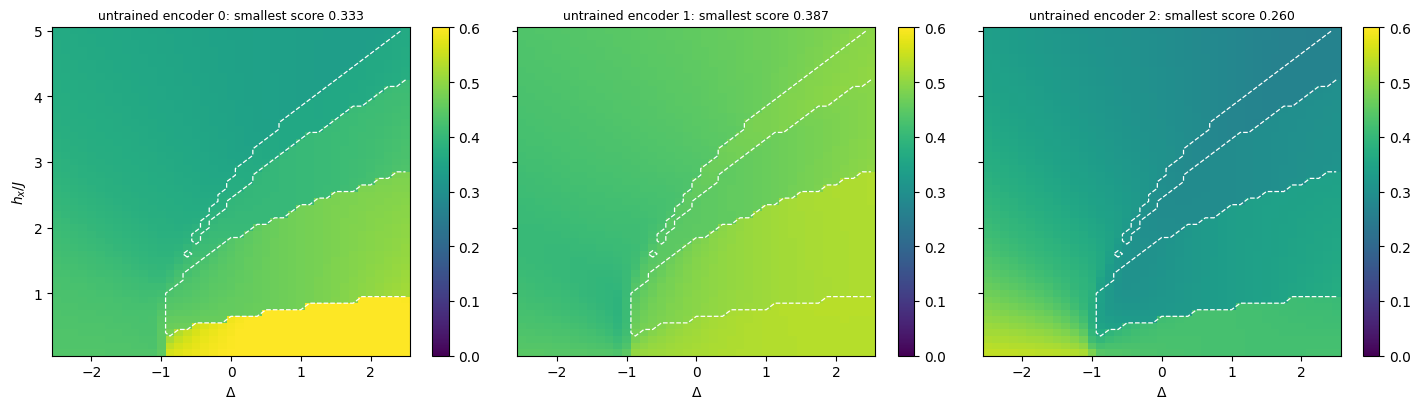

In [12]:
# ==============================================================================
# STEP 9: wrong control -- untrained encoders -- and what any map does at a level crossing
# ==============================================================================
# PARAMETERS
R_RAND = 16                                            # random (untrained) encoders

A_RAND = np.asarray(anomaly_map(random_starts(R_RAND, seed=30), trash_mask(2))).reshape((R_RAND,) + SHAPE)

cross_d = PARITY[:, 1:] != PARITY[:, :-1]              # neighbouring pairs (along Delta) across a parity change
cross_h = PARITY[1:, :] != PARITY[:-1, :]              # the same along h_x


def jump_stats(A):
    """Mean |A(lambda) - A(lambda')| over neighbouring pairs across a parity change, and over all other pairs."""
    jd, jh = np.abs(np.diff(A, axis=-1)), np.abs(np.diff(A, axis=-2))
    across = np.concatenate([jd[..., cross_d], jh[..., cross_h]], axis=-1).mean(axis=-1)
    other = np.concatenate([jd[..., ~cross_d], jh[..., ~cross_h]], axis=-1).mean(axis=-1)
    return across, other


acr_r, oth_r = jump_stats(A_RAND)
acr_t, oth_t = jump_stats(A_BEST)
min_r = A_RAND.reshape(R_RAND, -1).min(axis=1)
print(f"{R_RAND} untrained encoders (uniformly random angles), k = 2:")
print(f"  smallest score on the grid           : {mean_and_se(min_r)[0]:.3f} +- {mean_and_se(min_r)[1]:.3f}  "
      f"(range {min_r.min():.3f} .. {min_r.max():.3f})")
print(f"  grid points with A < {TAU}            : {int(np.sum(A_RAND < TAU))} of {R_RAND * n_pts}")
print(f"  mean jump across a parity change     : {mean_and_se(acr_r)[0]:.4f} +- {mean_and_se(acr_r)[1]:.4f}")
print(f"  mean jump between other neighbours   : {mean_and_se(oth_r)[0]:.4f} +- {mean_and_se(oth_r)[1]:.4f}")
print(f"  ratio of the two, per encoder        : {mean_and_se(acr_r / oth_r)[0]:.1f} +- "
      f"{mean_and_se(acr_r / oth_r)[1]:.1f}")
print("trained encoders (best start per reference point):")
for r, name in enumerate(ref_names):
    print(f"  {name:>12s}: smallest score {A_BEST[r].min():.1e}, area with A < {TAU} {np.mean(A_BEST[r] < TAU):.3f}, "
          f"jump across a parity change {acr_t[r]:.4f}, elsewhere {oth_t[r]:.4f}")
assert np.all(min_r > TAU)                              # no untrained encoder compresses any ground state

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True)
for a, ax in enumerate(axes):
    im = ax.pcolormesh(DELTAS, HXS, A_RAND[a], shading="nearest", cmap="viridis", vmin=0, vmax=0.6)
    draw_parity_lines(ax)
    ax.set_title(f"untrained encoder {a}: smallest score {A_RAND[a].min():.3f}", fontsize=9)
    ax.set_xlabel(r"$\Delta$"); ax.grid(False)
    fig.colorbar(im, ax=ax)
axes[0].set_ylabel(r"$h_x/J$")
fig.tight_layout(); plt.show()

No untrained encoder compresses any ground state. The smallest score on the grid is $0.340\pm0.016$ on average over
the 16 encoders and never below $0.16$, and none of the 32800 encoder–state pairs falls below $0.05$. The maps of
untrained encoders are nevertheless far from featureless: the score changes on average by $0.042$ between neighbouring
grid points on opposite sides of a parity change and by $0.0022$ between all other neighbours, a ratio of $19.5\pm1.4$.

For a fixed encoder, $D_H=\langle\psi_0(\lambda)\vert\,O\,\vert\psi_0(\lambda)\rangle$ with the
fixed observable $O=U^\dagger\bigl(\frac1k\sum_{j\in T}n_j\bigr)U$, and every expectation value jumps where the ground
state jumps. The level crossings of Section 3.2 are therefore visible to any encoder, trained or not. Three of the
trained encoders change more across a crossing ($0.10$ to $0.15$ for the ferromagnetic, large-field and Néel
encoders), the one trained in the middle band not more than an untrained one ($0.041$).

Two conclusions follow. A step in an anomaly map is no evidence by itself that the encoder has learned anything; its
position is a property of the spectrum of the finite chain. What training contributes is the zero level: a region
of states that the frozen encoder compresses, containing the reference point and bounded by such steps. Neither
the identity encoder (a flat map at $1/2$) nor random encoders (no compressed state at all) produce one.

### 6.3 The avoided crossing at small field

The maps of Section 6.1 come from one encoder per reference point. To see how much they depend on the training run,
we evaluate all successful encoders of Step 7 along two cuts through the plane, and compare them with exact data.
The first cut, $h_x=0.3J$ with $\Delta$ varying, crosses the avoided crossing at $\Delta\approx-1$: in the infinite
chain it passes from the ferromagnetic phase into the phase with Néel order along $y$, and at $\Delta=1$ into the one
with Néel order along $z$. The ground state has $P=+1$ along the whole cut.

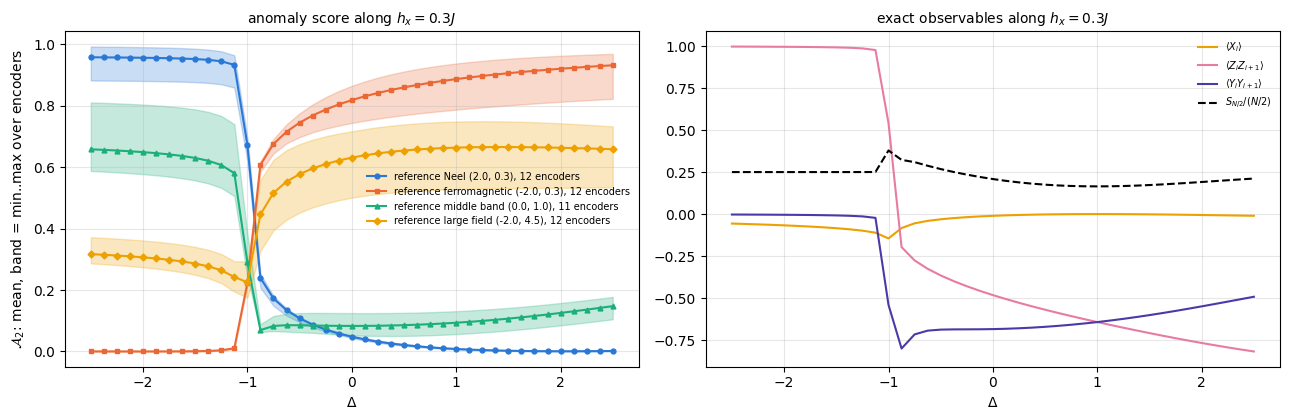

along h_x = 0.3: largest change of A between neighbouring grid points (mean over encoders), and where:
  reference          Neel: 0.433 between Delta = -1.000 and -0.875
  reference ferromagnetic: 0.385 between Delta = -1.000 and -0.875
  reference   middle band: 0.289 between Delta = -1.125 and -1.000
  reference   large field: 0.221 between Delta = -1.000 and -0.875
         Neel: 12 trained encoders; spread (max - min) of A over encoders: median over the grid 0.108, largest 0.205
ferromagnetic: 12 trained encoders; spread (max - min) of A over encoders: median over the grid 0.113, largest 0.166
  middle band: 11 trained encoders; spread (max - min) of A over encoders: median over the grid 0.238, largest 0.348
  large field: 12 trained encoders; spread (max - min) of A over encoders: median over the grid 0.083, largest 0.393


In [13]:
# ==============================================================================
# STEP 10: spread over trained starts, and the cut h_x = 0.3 compared with the exact observables
# ==============================================================================
A_ALL = {name: np.asarray(anomaly_map(jnp.asarray(TH_REF[r, OK_RUNS[name]]), trash_mask(2))).reshape(
    (len(OK_RUNS[name]),) + SHAPE) for r, name in enumerate(ref_names)}
i_cut = grid_index(0.0, 0.3)[0]


def plot_scores(ax, xs, take):
    """Mean anomaly score of the successful encoders of every reference point along a cut, band = min..max."""
    for r, name in enumerate(ref_names):
        a = take(A_ALL[name])
        ax.plot(xs, a.mean(axis=0), MARKERS[r] + "-", ms=3.5, color=PALETTE[r],
                label=f"reference {name} {REFS[name]}, {a.shape[0]} encoders")
        ax.fill_between(xs, a.min(axis=0), a.max(axis=0), color=PALETTE[r], alpha=0.25)
    ax.set_ylabel(r"$\mathcal{A}_2$: mean, band = min..max over encoders")


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.3), sharex=True)
plot_scores(axes[0], DELTAS, lambda A: A[:, i_cut, :])
axes[0].set_title(r"anomaly score along $h_x=0.3J$", fontsize=10); axes[0].legend(fontsize=7)
ax = axes[1]
ax.plot(DELTAS, MX[i_cut], "-", color=PALETTE[3], label=r"$\langle X_i\rangle$")
ax.plot(DELTAS, ZZC[i_cut], "-", color=PALETTE[4], label=r"$\langle Z_iZ_{i+1}\rangle$")
ax.plot(DELTAS, YYC[i_cut], "-", color=PALETTE[5], label=r"$\langle Y_iY_{i+1}\rangle$")
ax.plot(DELTAS, SHALF[i_cut] / (N // 2), "--", color="k", label=r"$S_{N/2}/(N/2)$")
ax.set_title(r"exact observables along $h_x=0.3J$", fontsize=10); ax.legend(fontsize=7)
for ax in axes:
    ax.set_xlabel(r"$\Delta$")
    for x_ in DELTAS[:-1][np.diff(PARITY[i_cut]) != 0]:
        ax.axvline(x_ + 0.5 * (DELTAS[1] - DELTAS[0]), color="grey", ls=":", lw=1.0)
fig.tight_layout(); plt.show()

print("along h_x = 0.3: largest change of A between neighbouring grid points (mean over encoders), and where:")
for name in ref_names:
    d = np.abs(np.diff(A_ALL[name][:, i_cut, :].mean(axis=0)))
    m = int(np.argmax(d))
    print(f"  reference {name:>13s}: {d[m]:.3f} between Delta = {DELTAS[m]:+.3f} and {DELTAS[m + 1]:+.3f}")
for name in ref_names:
    spread = A_ALL[name].max(axis=0) - A_ALL[name].min(axis=0)
    print(f"{name:>13s}: {A_ALL[name].shape[0]} trained encoders; spread (max - min) of A over encoders: "
          f"median over the grid {np.median(spread):.3f}, largest {spread.max():.3f}")

All four maps take their largest step at the avoided crossing: between $\Delta=-1$ and $-0.875$ for the Néel,
ferromagnetic and large-field encoders, between $-1.125$ and $-1$ for the middle-band encoder, the two intervals
across which the neighbour infidelity is $0.733$ and $0.436$. The exact $\langle Z_iZ_{i+1}\rangle$ and
$\langle Y_iY_{i+1}\rangle$ jump at the same place. The ferromagnetic and the Néel encoders see the boundary from its
two sides: the first compresses the ferromagnetic states (mean score $0.012$ in that region, Section 6.1) and its
score rises by $0.39$ across the crossing; the second scores $0.96$ there on average and drops by $0.43$ across the
crossing. This boundary is a genuine one: it is the finite-size image of the transition between the ferromagnetic
phase and the phase with Néel order along $y$, and both encoders locate it, each trained on a single state far from
it. The gapless line at $\Delta=1$, on the other hand, leaves no mark: the Néel encoder's score falls smoothly through
it, as do the exact observables.

The bands show how much the maps depend on the training run. Over the grid, the median spread between the largest
and the smallest score of the successful encoders is $0.08$ to $0.11$ for three references and $0.24$ for the
middle band, and the largest spread is between $0.17$ and $0.39$. The step positions are the same for every encoder;
the levels between the steps are not.

### 6.4 The order–disorder transition along $\Delta=-2$

Along $\Delta=-2$ the infinite chain has a field-induced transition from the ferromagnet along $z$ to the
field-polarised phase at $h_c\approx2.55J$ (Section 3.1), in the universality class of the transverse-field Ising
chain. The line is free of parity crossings, and the reference points $(-2,0.3)$ and $(-2,4.5)$ lie on its two
sides. At $N=8$ nothing in Section 3.2 is sharp here, so we use the finite-size tools of notebook 47 and follow them
over three chain lengths, $N=6$, $8$ and $10$. For chains this short a dense diagonalisation inside each parity sector
(dimension $2^{N-1}\le512$) gives all levels at once.

* The **fidelity susceptibility** of the ground state, written $\vert0\rangle$ here with excited levels $\vert m\rangle$
  (energy eigenstates, not qubit states), with respect to the field
  ([notebook 47, Section 7](../ch13_quantum_phase_transitions/47_quantum_phase_transitions.ipynb)),

  $$\chi_F(h_x)=\Bigl\lVert\partial_{h_x}\psi_0\Bigr\rVert^2
    =\sum_{m\ne0}\frac{\vert\langle m\vert\sum_iX_i\vert0\rangle\vert^2}{(E_m-E_0)^2},\tag{11}$$

  is the second-order coefficient of the neighbour infidelity, $1-\vert\langle\psi_0(h_x)\vert\psi_0(h_x+\delta)\rangle\vert^2
  \approx\chi_F\,\delta^2$, with $\partial_{h_x}\psi_0$ taken orthogonal to $\psi_0$. Equation (11) is the total
  susceptibility of the chain; the plots show $\chi_F/N$. Since $\sum_iX_i$ commutes with $P$, only states
  $\vert m\rangle$ of the ground-state sector contribute. For the Ising class $\chi_F/N$ develops a peak that grows
  with $N$ (as $N$ itself at large $N$, since $\nu=1$) and moves towards $h_c$.
* The **doublet splitting** $s_N=E_0^{P=-1}-E_0^{P=+1}$. In the ordered phase it is the tunnelling splitting of the
  two ferromagnetic states and vanishes exponentially with $N$; in the disordered phase it tends to a finite gap; at
  $h_c$ it falls as $1/N$ (dynamical exponent $z=1$). The curves $Ns_N$ for two sizes therefore cross near $h_c$,
  the locator of [notebook 47, Section 5](../ch13_quantum_phase_transitions/47_quantum_phase_transitions.ipynb).
* The **gap inside the even sector**, $E_1^{P=+1}-E_0^{P=+1}$, which has a minimum near the transition, and the
  **end-to-end correlator** $\langle Z_0Z_{N-1}\rangle$, a finite-chain stand-in for the squared order parameter.

One more relation connects the anomaly score with Eq. (11). Take the ground state real and normalised; then
$\partial_{h_x}\langle\psi_0\vert\psi_0\rangle=2\langle\partial_{h_x}\psi_0\vert\psi_0\rangle=0$, and for any fixed
observable $O$

$$\Bigl\vert\frac{d\langle O\rangle}{dh_x}\Bigr\vert
  =2\,\Bigl\vert{\rm Re}\,\bigl\langle\partial_{h_x}\psi_0\bigm\vert\bigl(O-\langle O\rangle\bigr)\psi_0\bigr\rangle\Bigr\vert
  \le2\sqrt{\chi_F}\;\lVert(O-\langle O\rangle)\psi_0\rVert ,\tag{12}$$

by the Cauchy–Schwarz inequality; the subtraction of $\langle O\rangle$ is allowed because the derivative is
orthogonal to $\psi_0$. The anomaly score is such an expectation value, with
$O=U^\dagger\bigl(\frac1k\sum_{j\in T}n_j\bigr)U$ (Section 6.2), whose eigenvalues lie in $[0,1]$, so that the last factor is at most
$1/2$ and $\vert d\mathcal A/dh_x\vert\le\sqrt{\chi_F}$, for a trained encoder and for an untrained one alike.
The score can change quickly only where the ground state does.

dense scans along Delta = -2.0 for N = (6, 8, 10): open chains at 99 fields, periodic chains at 11 fields around h_c, 41.1 s in total
N = 8: |E0(dense, even sector) - E0(Lanczos grid)| along the cut: 3.6e-14;  ground-state parity on the cut: {1}
smallest E0_odd - E0_even along the cut (no parity crossing if >= 0 up to round-off): N = 6: 1.5e-08, N = 8: 2.2e-11, N = 10: 5.7e-14

  N  peak of chi_F/N at h_x  height  min of even-sector gap at h_x   value
  6                    1.55   0.039                           1.40   2.532
  8                    1.85   0.045                           1.70   2.075
 10                    2.00   0.051                           1.90   1.746
crossing of N (E0_odd - E0_even), open     chains, N = 6, 8: h_x = 2.520
crossing of N (E0_odd - E0_even), periodic chains, N = 6, 8: h_x = 2.567
crossing of N (E0_odd - E0_even), open     chains, N = 8, 10: h_x = 2.531
crossing of N (E0_odd - E0_even), periodic chains, N = 8, 10: h_x = 2.559
h_c of the infinite chain

  largest infidelity between neighbouring grid points along the cut: 0.0036 at h_x = 1.85;  chi_F (N = 8) * 0.1^2 at its peak: 0.0036
  wrong control, 16 untrained encoders: steepest change at h_x = 0.15, 0.15, 0.15, 0.15, 0.25, 1.15, 1.55, 1.75, 1.75, 1.85, 1.85, 1.85, 1.85, 1.85, 2.15, 2.25

Eq. (12) on the cut, 63 encoders: largest ratio |Delta A / Delta h_x| / sqrt(chi_F) = 0.566;  largest |Delta A / Delta h_x| = 0.261
sqrt(chi_F) at N = 8: 0.372 at h_x = 0.1, 0.598 at the peak (h_x = 1.85), 0.092 at h_x = 5.0


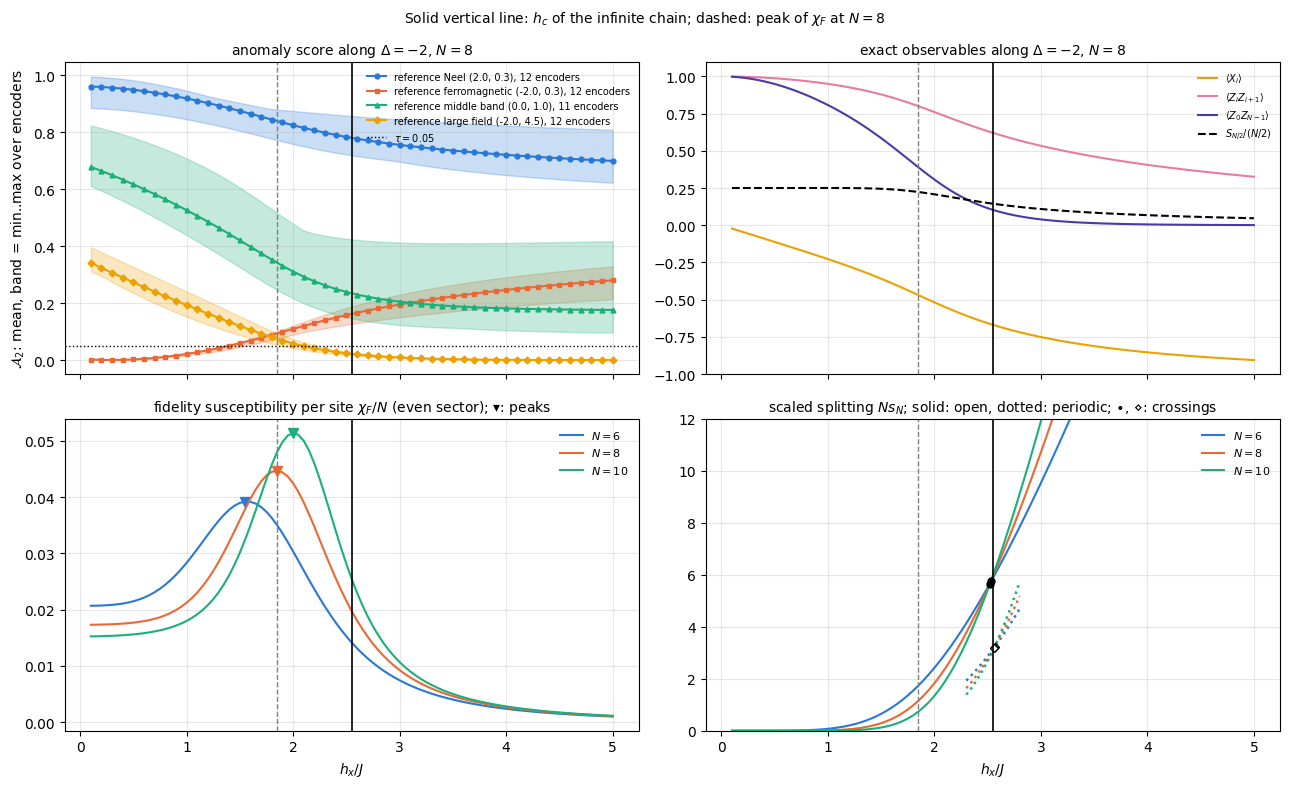

In [14]:
# ==============================================================================
# STEP 11: the cut Delta = -2 -- exact finite-size precursors for N = 6, 8, 10, and the anomaly scores at N = 8
# ==============================================================================
# PARAMETERS
D_CUT = -2.0                                           # the cut: ferromagnet along z -> field-polarised phase
NS_FSS = (6, 8, 10)                                    # chain lengths of the finite-size comparison (open chains)
H_FINE = np.round(np.arange(0.1, 5.0001, 0.05), 6)     # field values of the dense scan
H_PBC = np.round(np.arange(2.3, 2.8001, 0.05), 6)      # fields of the periodic-chain check around h_c
H_C_REF = 2.55                                         # h_c(Delta = -2) in units of J, read off Dmitriev et al., Fig. 1


def sector_basis(n, sign):
    """Orthonormal basis of the sector P = sign of n spins: (|s> + sign |s'>)/sqrt(2), s' = s with every bit flipped.

    P = prod_i X_i flips every bit, i.e. it maps the basis index s to 2^n - 1 - s; the strings with first bit 0
    label each pair {s, s'} once, so there are 2^(n-1) basis vectors."""
    dim = 2 ** n
    s = np.arange(dim // 2)
    B = np.zeros((dim, dim // 2))
    B[s, s] = 1 / np.sqrt(2)
    B[dim - 1 - s, s] = sign / np.sqrt(2)
    return B


def cut_spectrum(n, delta, hs, periodic=False):
    """Dense diagonalisation inside both parity sectors along a line of constant delta, for a chain of n spins
    (open, or periodic with the extra bond (n-1, 0)).

    Returns, per field value: E0 of the even and the odd sector, the gap E1 - E0 inside the even sector, the fidelity
    susceptibility per site of the even ground state, and its end-to-end correlator <Z_0 Z_{n-1}>.
    MATH   chi_F = sum_{m>0} |<m| sum_i X_i |0>|^2 / (E_m - E_0)^2  (notebook 47, Sec. 7), evaluated inside the even
           sector, which the derivative dH/dh_x = sum_i X_i does not leave.
    COST   the three parts of H are projected on the sectors once; then one dense eigendecomposition of dimension
           2^(n-1) per sector and field value (512 for n = 10).
    """
    dense = lambda t: np.real(np.asarray(dense_hamiltonian(t, n)))
    parts = [dense(heisenberg_terms(n, Jxx=J, Jyy=J, Jzz=0.0, periodic=periodic)),
             dense(heisenberg_terms(n, Jxx=0.0, Jyy=0.0, Jzz=J, periodic=periodic)), dense([((i,), X) for i in range(n)])]
    Be, Bo = sector_basis(n, +1), sector_basis(n, -1)
    xy_e, zz_e, x_e = [Be.T @ p @ Be for p in parts]                  # H restricted to P = +1
    xy_o, zz_o, x_o = [Bo.T @ p @ Bo for p in parts]                  # H restricted to P = -1
    z_end_e = Be.T @ dense([((0, n - 1), ZZ_)]) @ Be                  # Z_0 Z_{n-1} commutes with P
    out = []
    for h in hs:
        we, ve = np.linalg.eigh(xy_e + delta * zz_e + h * x_e)
        wo = np.linalg.eigvalsh(xy_o + delta * zz_o + h * x_o)
        m = ve.T @ x_e @ ve[:, 0]
        chi = np.sum(m[1:] ** 2 / (we[1:] - we[0]) ** 2) / n
        out.append((we[0], wo[0], we[1] - we[0], chi, ve[:, 0] @ z_end_e @ ve[:, 0]))
    return np.array(out)


t0 = time.perf_counter()
FSS = {n: cut_spectrum(n, D_CUT, H_FINE) for n in NS_FSS}
FSS_PBC = {n: cut_spectrum(n, D_CUT, H_PBC, periodic=True) for n in NS_FSS}
print(f"dense scans along Delta = {D_CUT} for N = {NS_FSS}: open chains at {H_FINE.size} fields, periodic chains at "
      f"{H_PBC.size} fields around h_c, {time.perf_counter() - t0:.1f} s in total")

# --- CHECKPOINT: the dense N = 8 scan reproduces the Lanczos grid on this line ------------------------------
j_cut = grid_index(D_CUT, 0.1)[1]
on_grid = np.isin(H_FINE, HXS)
err_e = np.max(np.abs(FSS[N][on_grid, 0] - np.asarray(E0_g).reshape(SHAPE)[:, j_cut]))
print(f"N = {N}: |E0(dense, even sector) - E0(Lanczos grid)| along the cut: {err_e:.1e};  "
      f"ground-state parity on the cut: {set(PARITY[:, j_cut].astype(int).tolist())}")
assert err_e < 1e-8 and np.all(PARITY[:, j_cut] > 0)
split_min = {n: float(np.min(FSS[n][:, 1] - FSS[n][:, 0])) for n in NS_FSS}
print("smallest E0_odd - E0_even along the cut (no parity crossing if >= 0 up to round-off): "
      + ", ".join(f"N = {n}: {v:.1e}" for n, v in split_min.items()))
assert all(v > -1e-10 for v in split_min.values())


def crossings(x, y):
    """Zeros of y(x) by linear interpolation between grid points."""
    k = np.where(np.diff(np.sign(y)) != 0)[0]
    return x[k] - y[k] * (x[k + 1] - x[k]) / (y[k + 1] - y[k])


print(f"\n{'N':>3s} {'peak of chi_F/N at h_x':>23s} {'height':>7s} {'min of even-sector gap at h_x':>30s} {'value':>7s}")
PEAK = {}
for n in NS_FSS:
    e0, e0o, gap, chi, zend = FSS[n].T
    PEAK[n] = H_FINE[np.argmax(chi)]
    print(f"{n:3d} {PEAK[n]:23.2f} {chi.max():7.3f} {H_FINE[np.argmin(gap)]:30.2f} {gap.min():7.3f}")
HC_FSS, HC_PBC = {}, {}
for n1, n2 in zip(NS_FSS[:-1], NS_FSS[1:]):
    for res, spec, hs, lab in ((HC_FSS, FSS, H_FINE, "open    "), (HC_PBC, FSS_PBC, H_PBC, "periodic")):
        y = n1 * (spec[n1][:, 1] - spec[n1][:, 0]) - n2 * (spec[n2][:, 1] - spec[n2][:, 0])
        res[(n1, n2)] = crossings(hs, y)
        print(f"crossing of N (E0_odd - E0_even), {lab} chains, N = {n1}, {n2}: h_x = "
              f"{', '.join(f'{x:.3f}' for x in res[(n1, n2)])}")
print(f"h_c of the infinite chain (Dmitriev et al., Fig. 1, mean-field line): about {H_C_REF} J")
assert PEAK[6] < PEAK[8] < PEAK[10] < H_C_REF                     # the fidelity peak drifts up towards h_c
assert all(len(x) == 1 and abs(x[0] - H_C_REF) < 0.1 for x in list(HC_FSS.values()) + list(HC_PBC.values()))
assert HC_FSS[(8, 10)][0] < HC_PBC[(8, 10)][0]                     # open and periodic chains bracket h_c

# --- the anomaly scores along the cut ----------------------------------------------------------------------
ref_cut = {name: A_ALL[name][:, :, j_cut] for name in ref_names}
mid = HXS[:-1] + 0.05
print(f"\nanomaly scores along Delta = {D_CUT} (N = {N}; mean over the successful encoders):")
print("  h_x           : " + " ".join(f"{h:6.1f}" for h in HXS[::4]))
for name in ref_names:
    print(f"  {name:13s} : " + " ".join(f"{a:6.3f}" for a in ref_cut[name].mean(axis=0)[::4]))
fer, lrg = ref_cut["ferromagnetic"], ref_cut["large field"]
last_f = [HXS[np.argmax(a >= TAU) - 1] for a in fer]                    # last field below tau, from the left
first_l = [HXS[len(HXS) - np.argmax(a[::-1] >= TAU)] for a in lrg]     # first field below tau, from the right
steep_f = [mid[np.argmax(np.diff(a))] for a in fer]
x_fl = crossings(HXS, fer.mean(axis=0) - lrg.mean(axis=0))
print(f"  ferromagnetic encoders: A < {TAU} up to h_x = {min(last_f):.1f}..{max(last_f):.1f}; steepest rise at "
      f"h_x = {min(steep_f):.2f}..{max(steep_f):.2f} (median {np.median(steep_f):.2f})")
print(f"  large-field encoders  : A < {TAU} from h_x = {min(first_l):.1f}..{max(first_l):.1f} upwards")
print(f"  the two mean scores cross at h_x = {', '.join(f'{x:.2f}' for x in x_fl)} "
      f"(score {np.interp(x_fl[0], HXS, fer.mean(axis=0)):.3f})")
nb_h = 1 - np.asarray(overlap2(PSI[:-1, j_cut], PSI[1:, j_cut]))        # infidelity between neighbours along h_x only
print(f"  largest infidelity between neighbouring grid points along the cut: {nb_h.max():.4f} at h_x = "
      f"{mid[np.argmax(nb_h)]:.2f};  chi_F (N = {N}) * 0.1^2 at its peak: {N * FSS[N][:, 3].max() * 0.01:.4f}")
A_RAND_CUT = A_RAND[:, :, j_cut]
steep_r = mid[np.argmax(np.abs(np.diff(A_RAND_CUT, axis=1)), axis=1)]
print(f"  wrong control, {R_RAND} untrained encoders: steepest change at h_x = "
      f"{', '.join(f'{x:.2f}' for x in np.sort(steep_r))}")

# --- CHECKPOINT: Eq. (12), |dA/dh_x| <= sqrt(chi_F), for every trained and untrained encoder on the cut ----------
chi_tot = N * FSS[N][:, 3]                                              # chi_F of the N = 8 ground state (not per site)
sqrt_chi = np.array([np.sqrt(chi_tot[(H_FINE > a - 1e-9) & (H_FINE < a + 0.1 + 1e-9)].max()) for a in HXS[:-1]])
slopes = np.abs(np.diff(np.concatenate([ref_cut[n] for n in ref_names] + [A_RAND_CUT]), axis=1)) / 0.1
print(f"\nEq. (12) on the cut, {slopes.shape[0]} encoders: largest ratio |Delta A / Delta h_x| / sqrt(chi_F) = "
      f"{(slopes / sqrt_chi).max():.3f};  largest |Delta A / Delta h_x| = {slopes.max():.3f}")
print(f"sqrt(chi_F) at N = {N}: {np.sqrt(chi_tot[0]):.3f} at h_x = {H_FINE[0]}, {np.sqrt(chi_tot.max()):.3f} at the peak "
      f"(h_x = {PEAK[N]}), {np.sqrt(chi_tot[-1]):.3f} at h_x = {H_FINE[-1]}")
assert np.all(slopes < sqrt_chi)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.0), sharex=True)
ax = axes[0, 0]
plot_scores(ax, HXS, lambda A: A[:, :, j_cut])
ax.axhline(TAU, color="k", ls=":", lw=1.0, label=fr"$\tau={TAU}$")
ax.set_title(r"anomaly score along $\Delta=-2$, $N=8$", fontsize=10); ax.legend(fontsize=7)
ax = axes[0, 1]
ax.plot(HXS, MX[:, j_cut], "-", color=PALETTE[3], label=r"$\langle X_i\rangle$")
ax.plot(HXS, ZZC[:, j_cut], "-", color=PALETTE[4], label=r"$\langle Z_iZ_{i+1}\rangle$")
ax.plot(H_FINE, FSS[N][:, 4], "-", color=PALETTE[5], label=r"$\langle Z_0Z_{N-1}\rangle$")
ax.plot(HXS, SHALF[:, j_cut] / (N // 2), "--", color="k", label=r"$S_{N/2}/(N/2)$")
ax.set_title(r"exact observables along $\Delta=-2$, $N=8$", fontsize=10); ax.legend(fontsize=7)
for c, n in enumerate(NS_FSS):
    e0, e0o, gap, chi, zend = FSS[n].T
    axes[1, 0].plot(H_FINE, chi, "-", color=PALETTE[c], label=f"$N={n}$")
    axes[1, 0].plot(PEAK[n], chi.max(), "v", color=PALETTE[c], ms=7)
    axes[1, 1].plot(H_FINE, n * (e0o - e0), "-", color=PALETTE[c], label=f"$N={n}$")
    axes[1, 1].plot(H_PBC, n * (FSS_PBC[n][:, 1] - FSS_PBC[n][:, 0]), ":", color=PALETTE[c], lw=1.8)
for x_c in HC_FSS.values():
    axes[1, 1].plot(x_c, np.interp(x_c, H_FINE, 8 * (FSS[8][:, 1] - FSS[8][:, 0])), "ko", ms=5)
for x_c in HC_PBC.values():
    axes[1, 1].plot(x_c, np.interp(x_c, H_PBC, 8 * (FSS_PBC[8][:, 1] - FSS_PBC[8][:, 0])), "kD", ms=4, mfc="w")
axes[1, 0].set_title(r"fidelity susceptibility per site $\chi_F/N$ (even sector); $\blacktriangledown$: peaks", fontsize=10)
axes[1, 1].set_title(r"scaled splitting $N s_N$; solid: open, dotted: periodic; $\bullet$, $\diamond$: crossings",
                     fontsize=10)
axes[1, 1].set_ylim(0, 12)
for ax in axes[1]:
    ax.legend(fontsize=8); ax.set_xlabel(r"$h_x/J$")
for ax in axes.flat:
    ax.axvline(H_C_REF, color="k", lw=1.2)
    ax.axvline(PEAK[N], color="grey", ls="--", lw=1.0)
fig.suptitle(r"Solid vertical line: $h_c$ of the infinite chain; dashed: peak of $\chi_F$ at $N=8$", fontsize=10)
fig.tight_layout(); plt.show()

**The exact precursors.** The dense scan at $N=8$ reproduces the Lanczos energies of the grid to $4\times10^{-14}$,
and the ground state has $P=+1$ along the whole cut. The peak of $\chi_F/N$ lies at $h_x=1.55J$, $1.85J$ and $2.00J$
for $N=6$, $8$ and $10$, and grows from $0.039$ to $0.051$; the minimum of the even-sector gap moves in step, from
$1.40J$ to $1.90J$. Both drift towards $h_c$, but slowly: on open chains this short the peak at $N=8$ sits $0.7J$
below $h_c$. The crossings of $Ns_N$ converge much faster. On open chains they lie at $h_x=2.520J$ ($N=6,8$) and
$2.531J$ ($N=8,10$) and move up with $N$; on periodic chains, which have no ends, they lie at $2.567J$ and
$2.559J$ and move down. If both sequences keep converging monotonically, they bracket the critical field,
$2.53J<h_c<2.56J$, in agreement with the $2.55J$ read off the mean-field line of Dmitriev *et al.* The
correlator $\langle Z_0Z_{N-1}\rangle$ falls from $1$ to nearly $0$ (top right panel). At $N=8$ the transition is a crossover, but a crossover whose position
moves with $N$ and whose $Ns_N$ crossings locate $h_c$. The neighbour infidelity explains why the maps of
Section 3.2 show nothing here: between neighbouring grid points along the cut it is at most $0.0036$, at
$h_x=1.85J$, which is $\chi_F\,\delta^2$ for the peak value $\chi_F\approx0.36$ at $N=8$ and the grid spacing
$\delta=0.1J$.

**The anomaly scores at $N=8$.** The two encoders trained on this line divide it into three parts. The
ferromagnetic encoder compresses the ground states up to $h_x=1.3J$ to $1.5J$, depending on the training run; the
large-field encoder compresses those from $1.9J$ to $2.3J$ upwards; in between, neither score is below
$\tau=0.05$. The two mean scores cross at $h_x=1.76J$, and the score of the ferromagnetic encoder rises fastest
at $h_x=1.75J$ to $1.95J$ (median $1.85J$), which coincides with the peak of $\chi_F$ at $N=8$. The Néel and the
middle-band encoders, trained on states of other phases, compress nothing on this line; their scores fall smoothly
with the field. With two references the anomaly map therefore separates, without any order parameter, the
ordered from the disordered states along the cut, and places the boundary between them at the precursor of the
transition, in the window where the exact ground state changes fastest.

The map does not locate $h_c$ of the infinite chain. At $h_x=2.55J$ the large-field encoder already compresses the
ground state; the boundary of the map sits at the finite-size precursor, $0.7J$ lower. The position of the steepest
rise is not specific to training either. Equation (12) holds for all 63 encoders on this line (the largest ratio of
slope to $\sqrt{\chi_F}$ is $0.57$), and ten of the 16 untrained encoders also change fastest between $1.55J$ and
$2.25J$; five change fastest at the low-field end of the grid ($h_x\le0.3J$) and one at $1.15J$. Equation (12) makes
this concentration plausible without enforcing it: $\sqrt{\chi_F}$ is largest, $0.60$, at $h_x=1.85J$, falls
to $0.09$ at $h_x=5J$, but is still $0.37$ at the low-field end. The bound therefore forbids fast changes deep in the
field-polarised phase, while at small field it leaves room for them. What training adds is again the zero level: the
two compressed regions, one on each side, which no untrained encoder produces. Moving the boundary of the map to
$h_c$ requires the same finite-size analysis as for the exact observables, with encoders trained at several $N$
(Exercise 6).

### 6.5 The number of trash qubits

The compressed subspace has dimension $2^{N-k}$: 128 for $k=1$, 16 for $k=4$. More trash qubits leave fewer
directions free, which suggests that the region of small scores shrinks with $k$; the training problem also becomes
harder. We test both. We repeat the
training at the Néel reference point for $k=1,2,3,4$ (trash registers in the `TRASH` table: always the outermost
qubits), eight starts each, and compare the maps of all successful encoders by three numbers: the area with
$\mathcal A<0.05$, the mean score on the odd-parity part of the middle band (all grid points with $P=-1$), and the
mean score in the ferromagnetic region ($\Delta\le-1.25$, $h_x\le1$).

32 training runs in 5.2 s (compilation included); the trash register is a traced mask, so all four k share one program
mean +- standard error over the successful encoders of each k:

  k  dim Q  success    68% Wilson     area A<0.05    mean A, P=-1  mean A, ferromagnetic


  1    128    8/8   [0.89, 1.00]  0.154 +- 0.010  0.178 +- 0.005         0.959 +- 0.005


  2     64    8/8   [0.89, 1.00]  0.160 +- 0.005  0.177 +- 0.005         0.935 +- 0.009


  3     32    7/8   [0.72, 0.95]  0.127 +- 0.012  0.185 +- 0.004         0.748 +- 0.037


  4     16    2/8   [0.13, 0.42]  0.149 +- 0.012  0.180 +- 0.006         0.691 +- 0.153


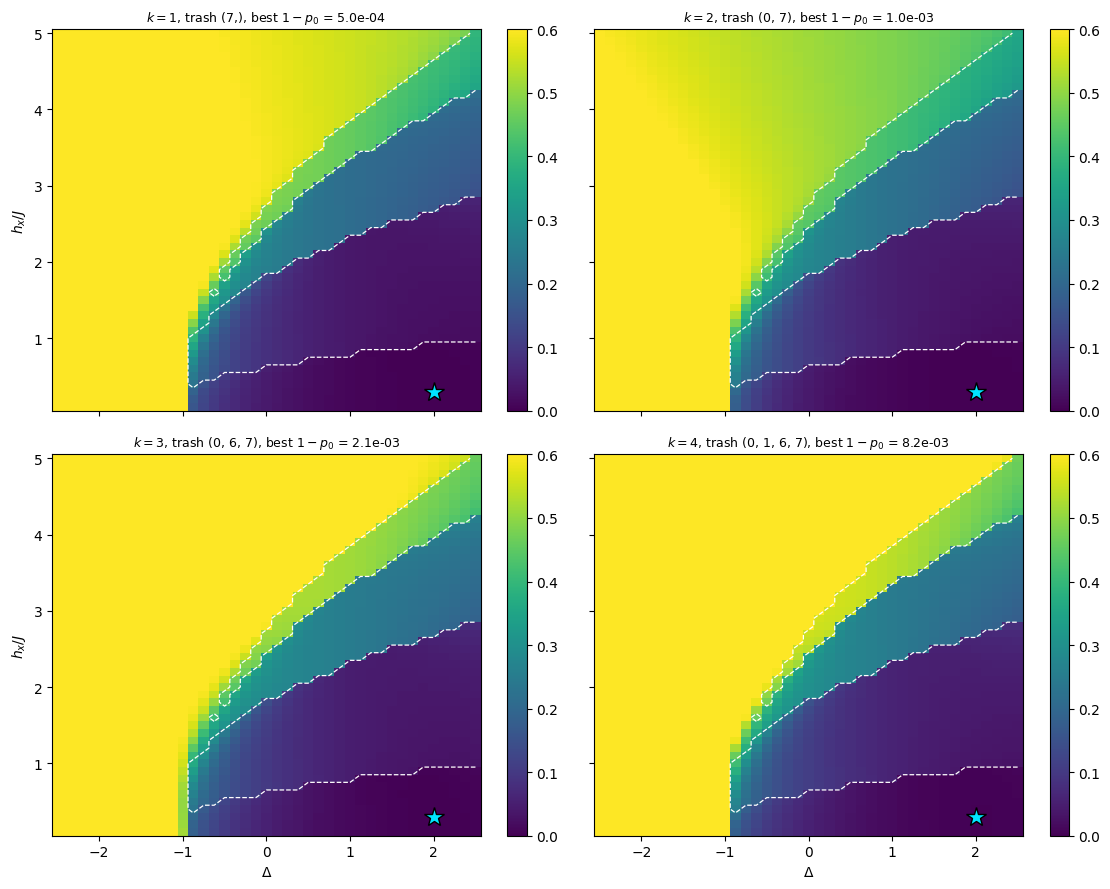

In [15]:
# ==============================================================================
# STEP 12: the number of trash qubits
# ==============================================================================
# PARAMETERS
R_K = 8                                                # starts per k
REF_K = "Neel"

psi_k = PSI[grid_index(*REFS[REF_K])]
ks = (1, 2, 3, 4)
B = len(ks) * R_K
th0 = random_starts(R_K, seed=40)
t0 = time.perf_counter()
TH_K, H_K = jax.block_until_ready(train_batch(
    jnp.tile(th0, (len(ks), 1)), jnp.broadcast_to(psi_k, (B,) + psi_k.shape),
    jnp.repeat(jnp.stack([trash_mask(k) for k in ks]), R_K, axis=0),
    jnp.zeros(B, dtype=RDTYPE), jnp.full(B, LR, dtype=RDTYPE)))
print(f"{B} training runs in {time.perf_counter() - t0:.1f} s (compilation included); the trash register is a traced "
      f"mask, so all four k share one program")
TH_K = np.asarray(TH_K).reshape(len(ks), R_K, N_PAR)
H_K = np.asarray(H_K).reshape(len(ks), R_K, N_STEPS, 2)

odd, left = PARITY < 0, (DD <= -1.25) & (HH <= 1.0)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0), sharex=True, sharey=True)
axes = axes.ravel()
print("mean +- standard error over the successful encoders of each k:")
print(f"\n{'k':>3s} {'dim Q':>6s} {'success':>8s} {'68% Wilson':>13s} {'area A<0.05':>15s} {'mean A, P=-1':>15s} "
      f"{'mean A, ferromagnetic':>22s}")
for a, k in enumerate(ks):
    fin = H_K[a, :, -1, 1]
    s = int(np.sum(fin < SUCCESS))
    lo, hi = wilson_interval(s, R_K)
    best = int(np.argmin(fin))
    A_ok = np.asarray(anomaly_map(jnp.asarray(TH_K[a, fin < SUCCESS]), trash_mask(k))).reshape((-1,) + SHAPE)
    A_k = np.asarray(anomaly_map(jnp.asarray(TH_K[a, best])[None], trash_mask(k))).reshape(SHAPE)
    area = (A_ok < TAU).reshape(A_ok.shape[0], -1).mean(axis=1)
    mo, ml = A_ok[:, odd].mean(axis=1), A_ok[:, left].mean(axis=1)
    fmt = lambda v: f"{v.mean():.3f} +- {v.std(ddof=1) / np.sqrt(v.size):.3f}" if v.size > 1 else f"{v.mean():.3f}"
    print(f"{k:3d} {2 ** (N - k):6d} {s:4d}/{R_K:<3d} [{lo:.2f}, {hi:.2f}] {fmt(area):>15s} {fmt(mo):>15s} "
          f"{fmt(ml):>22s}")
    im = axes[a].pcolormesh(DELTAS, HXS, A_k, shading="nearest", cmap="viridis", vmin=0, vmax=0.6)
    draw_parity_lines(axes[a])
    axes[a].plot(*REFS[REF_K], "*", ms=15, color="#00e5ff", mec="k")
    axes[a].set_title(f"$k={k}$, trash {TRASH[k]}, best $1-p_0$ = {fin.min():.1e}", fontsize=9)
    axes[a].grid(False)
    fig.colorbar(im, ax=axes[a])
for a in (0, 2):
    axes[a].set_ylabel(r"$h_x/J$")
for a in (2, 3):
    axes[a].set_xlabel(r"$\Delta$")
fig.tight_layout(); plt.show()

Training becomes harder as $k$ grows: all starts succeed for $k=1$ and $k=2$, seven of eight for $k=3$, two of eight
for $k=4$. The maps, however, do not shrink with $k$. Over the successful encoders the area with $\mathcal A<0.05$ is
$0.154$, $0.160$, $0.127$ and $0.149$ for $k=1,\dots,4$, with standard errors of $0.005$ to $0.012$: no monotonic
decrease. The mean score on the odd-parity points is $0.18$–$0.19$ for every $k$. Only in the ferromagnetic region
does the score fall with $k$, from $0.96$ ($k=1$) to $0.75$ ($k=3$); the value for $k=4$ rests on two encoders. Reducing
the compressed subspace from 128 to 16 dimensions does not, in this test, reduce the region that the frozen encoder
compresses; what fills that region is decided by the ansatz and the training run as much as by the dimension count.

The maps of the best encoders show the same edges for every $k$: the avoided crossing at $\Delta\approx-1$ and the
parity changes.

## 7. Limitations

* **Finite size.** At $N=8$ the sharp features of the phase diagram are level crossings and avoided crossings of a
  finite spectrum, and their positions move with $N$ (Exercise 6). The parity crossings, $N/2$ of them along a line of
  increasing field, lie inside the ordered phases of the infinite chain and mark no transition; only the avoided
  crossing at $\Delta\approx-1$ corresponds to a phase boundary. The order–disorder transition appears here as a
  smooth crossover whose precursors lie well below $h_c$ (the peak of $\chi_F$ at $1.85J$ against $h_c\approx2.55J$
  along $\Delta=-2$), and the gapless line at $\Delta=1$ leaves no trace. A step or an edge in an anomaly map is
  therefore at best a finite-size precursor of a transition, and often not even that; establishing a transition and
  its critical field requires the finite-size analysis of notebook 47, as the crossings of $Ns_N$ in
  Section 6.4 illustrate.
* **What the steps encode.** Section 6.2 showed that the steps sit where the ground state jumps and that untrained
  encoders show them too. The information specific to training is the region of small score, and its extent depends on
  the training run, on the threshold $\tau$, and on directions of the compressed subspace that training does not fix.
* **One-sided bound.** Equation (9) guarantees a small score for states that overlap strongly with the reference
  state. Nothing guarantees a large score for states of a different phase: in Section 6.1 the Néel encoder compressed
  middle-band states orthogonal to its reference.
* **Cost of the scan.** Every grid point needs its own ground state, prepared on a device by a variational or
  adiabatic algorithm, and enough shots to estimate $D_H$ to the resolution of the steps one wants to see. The standard
  error of $D_H$ from $M$ shots is $\sqrt{\mathrm{Var}(w)/M}/k$; Exercise 3 turns this into a shot budget. In this
  notebook the classical cost is dominated by the 4100 Lanczos runs and the dense scans of Section 6.4; training and
  the scan take seconds.
* **Trainability at larger sizes.** At $k=2$ the local and global costs trained equally well, and for $k\le4$ their
  gradient variances differ by at most a factor of two. The advantage of the local cost is a statement about scaling
  with the number of qubits, which these sizes cannot test.

## 8. Key takeaways

* **The anomaly score is a local cost with two exact bounds.** $D_H\le1-p_0\le kD_H$ connects it to the global trash
  infidelity, $F_{\rm rec}\ge(1-kD_H)^2$ to the reconstruction fidelity, and Eq. (9) bounds the score of a frozen
  encoder by the infidelity of the input with the training state. Equations (6) and (9) were checked numerically
  (6000 random pairs, and every grid point for four trained encoders), and Eq. (12) bounds how fast any score can
  change by the fidelity susceptibility of the ground state.
* **Exact reference first.** The 2050 ground states of $H(\Delta,h_x)$ at $N=8$, computed by Lanczos in the two
  sectors of $P=\prod_iX_i$, show three kinds of behaviour: level crossings between parity sectors, an avoided
  crossing at $\Delta\approx-1$ (gap $0.043$), and smooth crossovers. Only the avoided crossing is the image of a
  phase boundary of the infinite chain; the parity crossings are the split symmetry-broken doublet of its ordered
  phases, and the order–disorder transition is a crossover at this size.
* **Training on one state is easy at this size.** With the step size bracketed for both costs, every one of 48 runs
  succeeded ($1-p_0<10^{-2}$), and 47 of 48 at four reference points. Local and global costs trained equally well
  at $k=2$, and their gradient variances differ by at most a factor of two for $k\le4$.
* **Frozen encoders compress far beyond the training state.** The regions with score below $0.05$ cover $7$ to
  $44\,\%$ of the plane, against $4$ to $19\,\%$ with overlap above $0.95$ with the reference state, and include
  states orthogonal to it.
* **Two phase boundaries are seen without an order parameter.** Along $h_x=0.3J$ the ferromagnetic and the Néel
  encoders, trained far from it, both place their edge at the avoided crossing that marks the boundary between the
  ferromagnet and the Néel order along $y$. Along $\Delta=-2$ the ferromagnetic and the large-field encoders compress
  the two sides of the order–disorder transition and leave a window between $1.3J$–$1.5J$ and $1.9J$–$2.3J$ that
  contains the peak of $\chi_F$ at $N=8$ ($1.85J$), the finite-size precursor of the transition.
* **The map finds the finite-size precursor and leaves $h_c$ to finite-size scaling.** The fidelity peak moves
  from $1.55J$ to $2.00J$ between $N=6$ and $10$, while the crossings of $Ns_N$ on open and periodic chains
  bracket $h_c$ between $2.53J$ and $2.56J$, in agreement with $2.55J$ from Dmitriev *et al.*; the map at $N=8$
  places the boundary $0.7J$ below $h_c$.
* **The edges are where the ground state changes.** The steps of every map coincide with the level crossings and the
  avoided crossing. On the smooth line $\Delta=-2$ the trained scores change fastest near the peak of $\chi_F$, and
  Eq. (12) bounds the slope of every score by $\sqrt{\chi_F}$.
  Untrained encoders show the same steps ($20$ times larger across a parity change than elsewhere) but compress no
  state; the identity encoder gives exactly $1/2$ everywhere by symmetry. What training adds is the region of
  compressed states.
* **More trash qubits make training harder without shrinking the map.** Success fell from $8/8$ ($k=1,2$) to $2/8$
  ($k=4$); the area of small score stayed between $0.13$ and $0.16$, with no monotonic trend.

## 9. Exercises

1. ★ **Equality cases of Eq. (6).** Find the conditions on the distribution $p(t)$ of the trash strings under which
   $D_H=1-p_0$, and under which $1-p_0=kD_H$. For $k=2$, construct encoded states that attain each of them (a latent
   state tensored with chosen trash strings) and check with `trash_costs`.
2. ★ **Breaking the symmetry (physics).** Add a longitudinal field $h_z\sum_iZ_i$ with $h_z=0.1$ to Eq. (1). The
   parity is no longer conserved, so compute the ground states with `lanczos_lowest` without the projector. Evaluate the
   identity encoder of Eq. (10) on the new grid. Is its map still flat? Which exact observable does it reproduce?
3. ★★ **Shot budget.** On hardware, $D_H$ is estimated from $M$ measurements of the $k$ trash bits, with standard error
   $\sqrt{\mathrm{Var}(w)/M}/k$. For the frozen ferromagnetic and Néel encoders, compute the distribution of $w$ at
   every grid point of the cut $h_x=0.3J$ and the number of shots per point needed to resolve the step at the avoided
   crossing at three standard errors. Repeat for the ferromagnetic encoder along $\Delta=-2$: how many shots are
   needed to tell the score at $h_x=1.8J$ from that at $1.9J$? Check one answer by sampling.
4. ★★ **Position of the trash register (extend the code).** Add the adjacent pair $(6,7)$ to `TRASH`, train 16 starts at
   the Néel reference point with it and with the pair $(0,7)$, and compare the success fractions and the median final
   $1-p_0$. Repeat with fewer layers.
5. ★★ **The other sign of $J$ (physics).** Repeat Sections 3 and 6.1 for $J=-1$. Which parity sectors does the ground
   state visit, how many sharp lines does the exact phase diagram have, and what do the maps of encoders trained at
   $(0,2.5)$, $(2,0.3)$ and $(-2,0.3)$ look like?
6. ★★★ **Finite size.** (a) Train ferromagnetic and large-field encoders ($L=4$, trash at the ends) at $(-2,0.3)$
   and $(-2,4.5)$ for $N=6$ and $N=10$, and evaluate them along $\Delta=-2$. Do the steepest rise of the ferromagnetic
   score, the crossing of the two mean scores and the edges of the two compressed regions move with $N$ as the peak of
   $\chi_F$ does? Can any of them be extrapolated to $h_c$? (b) Along $\Delta=2$, count the parity crossings for
   $N=6$, $8$, $10$ up to $h_x=6J$ and compare the last one with the classical line $h_x^{\rm cl}=2\sqrt6J$ for an
   open and for a periodic chain. Where does the anomaly score of a Néel encoder step, and why do these steps mark no
   transition?

## References

* K. Kottmann, F. Metz, J. Fraxanet and N. Baldelli, *Variational quantum anomaly detection: Unsupervised mapping of
  phase diagrams on a physical quantum computer*, Phys. Rev. Research **3**, 043184 (2021) — the protocol of this
  notebook: a circuit inspired by the quantum autoencoder, trained on a single ground state with the Hamming-distance
  cost on the trash qubits; extended Bose–Hubbard model with dimerised hoppings and a transverse–longitudinal-field Ising chain, the latter
  also on an IBM quantum computer.
* K. Kottmann, P. Huembeli, M. Lewenstein and A. Acín, *Unsupervised phase discovery with deep anomaly detection*,
  Phys. Rev. Lett. **125**, 170603 (2020) — anomaly detection with deep neural networks for the phase diagram of the
  extended Bose–Hubbard model.
* J. Romero, J. P. Olson and A. Aspuru-Guzik, *Quantum autoencoders for efficient compression of quantum data*,
  Quantum Sci. Technol. **2**, 045001 (2017) — the quantum autoencoder and its trash-state cost.
* M. Cerezo, A. Sone, T. Volkoff, L. Cincio and P. J. Coles, *Cost function dependent barren plateaus in shallow
  parametrized quantum circuits*, Nat. Commun. **12**, 1791 (2021) — global costs give exponentially vanishing
  gradients already at shallow depth, local costs at worst polynomially vanishing ones at logarithmic depth; illustrated
  with a quantum autoencoder.
* D. V. Dmitriev, V. Ya. Krivnov, A. A. Ovchinnikov and A. Langari, *One-dimensional anisotropic Heisenberg model in
  the transverse magnetic field*, J. Exp. Theor. Phys. **95**, 538 (2002) — the ground-state phase diagram of the
  infinite XXZ chain in a transverse field: the ordered phases, the classical line, the Ising-type transition line
  $h_c(\Delta)$ (their Fig. 1), and the parity crossings of finite chains.
* P. Zanardi and N. Paunković, *Ground state overlap and quantum phase transitions*, Phys. Rev. E **74**, 031123
  (2006) — the overlap of ground states at neighbouring couplings as a detector of transitions (the neighbour
  infidelity of Section 3.2).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/